<a href="https://colab.research.google.com/github/SageChisanga/Data-Science/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authors: Chisanga Kabwe, Henk Gouws, and ADEWUMI SAMUEL ADEFEHINTI

#Imports

In [1]:
# @title pip installation of pyts
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.9 MB/s eta 0:00:00


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
from sklearn import metrics
warnings.filterwarnings('ignore')

from pyts.image import GramianAngularField
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix



#Step 1A



In [ ]:
#download the financial data
tick = "ETH-USD"
eth_data = yf.download(tick, period="1y", interval="4h")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
eth_data.info()
eth_data.head()
edf2k = eth_data.tail(2000)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2191 entries, 2024-05-22 16:00:00+00:00 to 2025-05-22 16:00:00+00:00
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, ETH-USD)   2191 non-null   float64
 1   (High, ETH-USD)    2191 non-null   float64
 2   (Low, ETH-USD)     2191 non-null   float64
 3   (Open, ETH-USD)    2191 non-null   float64
 4   (Volume, ETH-USD)  2191 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 102.7 KB


##Clean up and get data ready

In [ ]:
edf = edf2k.copy()
edf['returns'] = edf['Close'].pct_change()
edf['log_price'] = np.log(edf['Close'])
edf['log_returns'] = edf['log_price'].diff()
edf.dropna(inplace=True)
edf.head()

Price,Close,High,Low,Open,Volume,returns,log_price,log_returns
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD,,,
Datetime,,,,,,,,
2024-06-23 16:00:00+00:00,3476.434814,3478.508057,3461.407227,3472.614014,453107200,0.001385,8.153763,0.001384
2024-06-23 20:00:00+00:00,3418.294922,3477.653320,3408.583008,3477.653320,1652614656,-0.016724,8.136897,-0.016865
2024-06-24 00:00:00+00:00,3401.776367,3429.953857,3391.192383,3418.783203,1696828416,-0.004832,8.132053,-0.004844
2024-06-24 04:00:00+00:00,3368.948242,3410.029297,3355.392334,3400.775391,1960707072,-0.009650,8.122356,-0.009697
2024-06-24 08:00:00+00:00,3318.611328,3390.923584,3276.458740,3367.245850,3985838080,-0.014941,8.107302,-0.015054


Summary statistics of the main data without any transformation

In [ ]:
edf['Close'].describe()

Ticker,ETH-USD
count,1999.000000
mean,2726.231010
std,611.101298
min,1417.378662
25%,2366.827271
50%,2645.841553
75%,3278.443604
max,4074.922119


In [ ]:
skewness = edf['Close'].skew()
kurtosis = edf['Close'].kurtosis()
cv = edf['Close'].std() / edf['Close'].mean()
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")
print(f"Coefficient of Variation: {cv}")

Skewness: Ticker
ETH-USD   -0.029973
dtype: float64
Kurtosis: Ticker
ETH-USD   -0.810481
dtype: float64
Coefficient of Variation: Ticker
ETH-USD    0.224156
dtype: float64


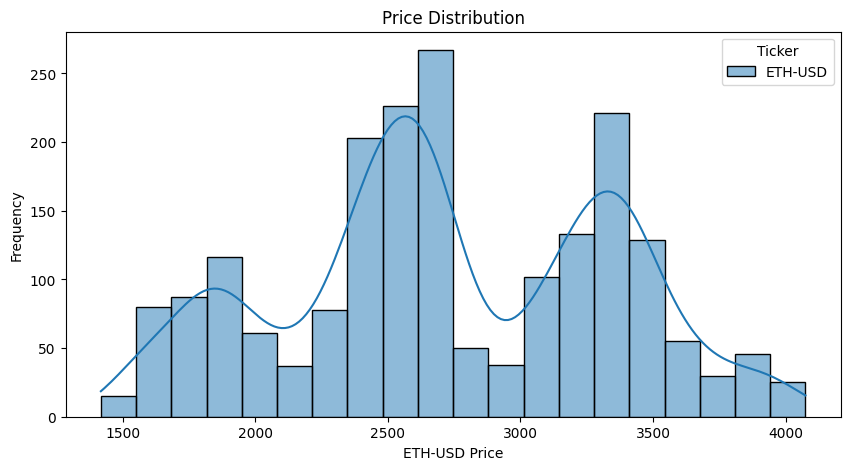

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(edf['Close'], bins=20, kde=True, color='skyblue')
plt.title("Price Distribution")
plt.xlabel("ETH-USD Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
def enhanced_describe(series):
    """Enhanced descriptive statistics"""
    stats_dict = {
        'count': len(series),
        '--------------------------':'',
        'mean': series.mean(),
        '--------------------------':'',
        'median': series.median(),
        '--------------------------':'',
        'std': series.std(),
        '--------------------------':'',
        'var': series.var(),
        '--------------------------':'',
        'min': series.min(),
        '--------------------------':'',
        'max': series.max(),
        '--------------------------':'',
        'range': series.max() - series.min(),
        '--------------------------':'',
        'q25': series.quantile(0.25),
        '--------------------------':'',
        'q50': series.quantile(0.50),
        '--------------------------':'',
        'q75': series.quantile(0.75),
        '--------------------------':'',
        'q75': series.quantile(0.75),
        '--------------------------':'',
        'iqr': series.quantile(0.75) - series.quantile(0.25),
        '--------------------------':'',
        'skewness': stats.skew(series.dropna()),
        '--------------------------':'',
        'kurtosis': stats.kurtosis(series.dropna()),
        '--------------------------':'',
        'cv': series.std() / series.mean() if series.mean() != 0 else np.nan,  # Coefficient of variation
    }
    return pd.Series(stats_dict)

print("\nEnhanced Statistics for Returns:")
print(enhanced_describe(edf['returns']))


Enhanced Statistics for Returns:
count                                1999
--------------------------               
mean                            -0.000011
median                           0.000232
std                              0.015676
var                              0.000246
min                             -0.134409
max                              0.114001
range                             0.24841
q25                             -0.006861
q50                              0.000232
q75                              0.007025
iqr                              0.013886
skewness                        -0.354764
kurtosis                         9.739783
cv                           -1408.321555
dtype: object


## Distribution Analysis

In [ ]:
def distribution_analysis(series, name="Series"):
    print(f"\n{name} Distribution Analysis:")

    try:
        # Shapiro-Wilk (note: scipy.stats has size limitations)
        if len(series) <= 5000:
            shapiro_stat, shapiro_p = stats.shapiro(series.dropna())
            print(f"Shapiro-Wilk Test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

        # Jarque-Bera (good for financial data)
        jb_stat, jb_p = stats.jarque_bera(series.dropna())
        print(f"Jarque-Bera Test: statistic={jb_stat:.4f}, p-value={jb_p:.4f}")

    except Exception as e:
        print(f"Error in normality tests: {e}")

    # Distribution parameters
    print(f"Skewness: {stats.skew(series.dropna()):.4f}")
    print(f"Excess Kurtosis: {stats.kurtosis(series.dropna()):.4f}")

    # Percentiles
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
    percs = series.quantile([p/100 for p in percentiles])
    print("Percentiles:")
    for p in percentiles:
        print(f"  {p}%: {percs[p/100]:.6f}")

distribution_analysis(edf['returns'], "Returns")
distribution_analysis(edf['log_returns'], "Log Returns")



Returns Distribution Analysis:
Shapiro-Wilk Test: statistic=0.8993, p-value=0.0000
Jarque-Bera Test: statistic=7943.2599, p-value=0.0000
Skewness: -0.3548
Excess Kurtosis: 9.7398
Percentiles:
  1%: -0.047841
  5%: -0.023049
  10%: -0.015946
  25%: -0.006861
  50%: 0.000232
  75%: 0.007025
  90%: 0.015234
  95%: 0.022672
  99%: 0.042701

Log Returns Distribution Analysis:
Shapiro-Wilk Test: statistic=0.8950, p-value=0.0000
Jarque-Bera Test: statistic=9400.2112, p-value=0.0000
Skewness: -0.6355
Excess Kurtosis: 10.5472
Percentiles:
  1%: -0.049023
  5%: -0.023318
  10%: -0.016074
  25%: -0.006885
  50%: 0.000232
  75%: 0.007000
  90%: 0.015119
  95%: 0.022419
  99%: 0.041814


##Stationarity tests

In [ ]:
def stationarity_tests(series, name="Series"):
    """Comprehensive stationarity testing"""
    print(f"\n{name} Stationarity Tests:")

    # Augmented Dickey-Fuller Test
    try:
        adf_result = adfuller(series.dropna(), autolag='AIC')
        print(f"ADF Test: statistic={adf_result[0]:.4f}, p-value={adf_result[1]:.4f}")
        print(f"ADF Critical Values: {adf_result[4]}")
        print(f"ADF Conclusion: {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"ADF Test Error: {e}")

    # KPSS Test (null hypothesis: stationary)
    try:
        kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
        print(f"KPSS Test: statistic={kpss_result[0]:.4f}, p-value={kpss_result[1]:.4f}")
        print(f"KPSS Critical Values: {kpss_result[3]}")
        print(f"KPSS Conclusion: {'Stationary' if kpss_result[1] > 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"KPSS Test Error: {e}")

stationarity_tests(edf['Close'], "ETH Price")
stationarity_tests(edf['returns'], "Returns")
stationarity_tests(edf['log_returns'], "Log Returns")



ETH Price Stationarity Tests:
ADF Test: statistic=-1.8335, p-value=0.3640
ADF Critical Values: {'1%': np.float64(-3.4336536273681078), '5%': np.float64(-2.862999357426174), '10%': np.float64(-2.567546900734257)}
ADF Conclusion: Non-stationary
KPSS Test: statistic=2.0034, p-value=0.0100
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
KPSS Conclusion: Non-stationary

Returns Stationarity Tests:
ADF Test: statistic=-18.0742, p-value=0.0000
ADF Critical Values: {'1%': np.float64(-3.4336370214482437), '5%': np.float64(-2.862992025899885), '10%': np.float64(-2.5675429970585153)}
ADF Conclusion: Stationary
KPSS Test: statistic=0.1326, p-value=0.1000
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
KPSS Conclusion: Stationary

Log Returns Stationarity Tests:
ADF Test: statistic=-17.9941, p-value=0.0000
ADF Critical Values: {'1%': np.float64(-3.4336370214482437), '5%': np.float64(-2.862992025899885), '10%': np.float64(-2.56754299705851

In [ ]:
## Persistance

In [ ]:
def persistence_analysis(series, name="Series", max_lags=20):
    """Analyze persistence and autocorrelation"""
    print(f"\n{name} Persistence Analysis:")

    # Autocorrelation Function (ACF)
    try:
        acf_values, acf_confint = acf(series.dropna(), nlags=max_lags, alpha=0.05)
        print(f"ACF at lag 1: {acf_values[1]:.4f}")
        print(f"ACF at lag 5: {acf_values[5]:.4f}")
        print(f"ACF at lag 10: {acf_values[10]:.4f}")

        # Partial Autocorrelation Function (PACF)
        pacf_values, pacf_confint = pacf(series.dropna(), nlags=max_lags, alpha=0.05)
        print(f"PACF at lag 1: {pacf_values[1]:.4f}")

        # Ljung-Box Test for autocorrelation
        lb_test = acorr_ljungbox(series.dropna(), lags=10, return_df=True)
        print(f"Ljung-Box Test (lag 10): statistic={lb_test['lb_stat'].iloc[-1]:.4f}, "
              f"p-value={lb_test['lb_pvalue'].iloc[-1]:.4f}")
        print(f"Autocorrelation Present: {'Yes' if lb_test['lb_pvalue'].iloc[-1] < 0.05 else 'No'}")

        # Half-life of shocks (for mean-reverting series)
        if abs(acf_values[1]) < 1:
            half_life = np.log(0.5) / np.log(abs(acf_values[1])) if acf_values[1] != 0 else np.inf
            print(f"Half-life of shocks: {half_life:.2f} periods")

    except Exception as e:
        print(f"Error in persistence analysis: {e}")

persistence_analysis(edf['returns'], "Returns")
persistence_analysis(edf['log_returns'], "Log Returns")



Returns Persistence Analysis:
ACF at lag 1: -0.0006
ACF at lag 5: -0.0951
ACF at lag 10: 0.0268
PACF at lag 1: -0.0006
Ljung-Box Test (lag 10): statistic=41.7574, p-value=0.0000
Autocorrelation Present: Yes
Half-life of shocks: 0.09 periods

Log Returns Persistence Analysis:
ACF at lag 1: 0.0001
ACF at lag 5: -0.0937
ACF at lag 10: 0.0258
PACF at lag 1: 0.0001
Ljung-Box Test (lag 10): statistic=41.8353, p-value=0.0000
Autocorrelation Present: Yes
Half-life of shocks: 0.08 periods


##Volatility Analysis

In [ ]:
def volatility_analysis(series, window=30):
    """Analyze volatility characteristics"""
    print(f"\nVolatility Analysis:")

    # Rolling volatility
    rolling_vol = series.rolling(window=window).std()
    print(f"Mean Rolling Volatility ({window} periods): {rolling_vol.mean():.6f}")
    print(f"Volatility of Volatility: {rolling_vol.std():.6f}")

    # Volatility clustering analysis
    squared_returns = series ** 2
    print(f"Mean Squared Returns: {squared_returns.mean():.6f}")

    # Check volatility clustering via ACF of squared returns
    try:
        acf_squared = acf(squared_returns.dropna(), nlags=1)[1]
        print(f"Volatility Clustering (ACF of squared returns at lag 1): {acf_squared:.4f}")
    except:
        print("Could not calculate volatility clustering metric")

    # Risk metrics (VaR and Expected Shortfall)
    var_95 = series.quantile(0.05)
    var_99 = series.quantile(0.01)
    print(f"Value at Risk (95%): {var_95:.6f}")
    print(f"Value at Risk (99%): {var_99:.6f}")

    # Expected Shortfall (Conditional VaR)
    es_95 = series[series <= var_95].mean() if any(series <= var_95) else np.nan
    es_99 = series[series <= var_99].mean() if any(series <= var_99) else np.nan
    print(f"Expected Shortfall (95%): {es_95:.6f}")
    print(f"Expected Shortfall (99%): {es_99:.6f}")

    # Annualized volatility (assuming hourly data)
    annualized_vol = series.std() * np.sqrt(24 * 365)  # 24 hours * 365 days
    print(f"Annualized Volatility: {annualized_vol:.2%}")

volatility_analysis(edf['returns'])


Volatility Analysis:
Mean Rolling Volatility (30 periods): 0.014394
Volatility of Volatility: 0.006262
Mean Squared Returns: 0.000246
Volatility Clustering (ACF of squared returns at lag 1): 0.1096
Value at Risk (95%): -0.023049
Value at Risk (99%): -0.047841
Expected Shortfall (95%): -0.037999
Expected Shortfall (99%): -0.067115
Annualized Volatility: 146.72%


## Graphs

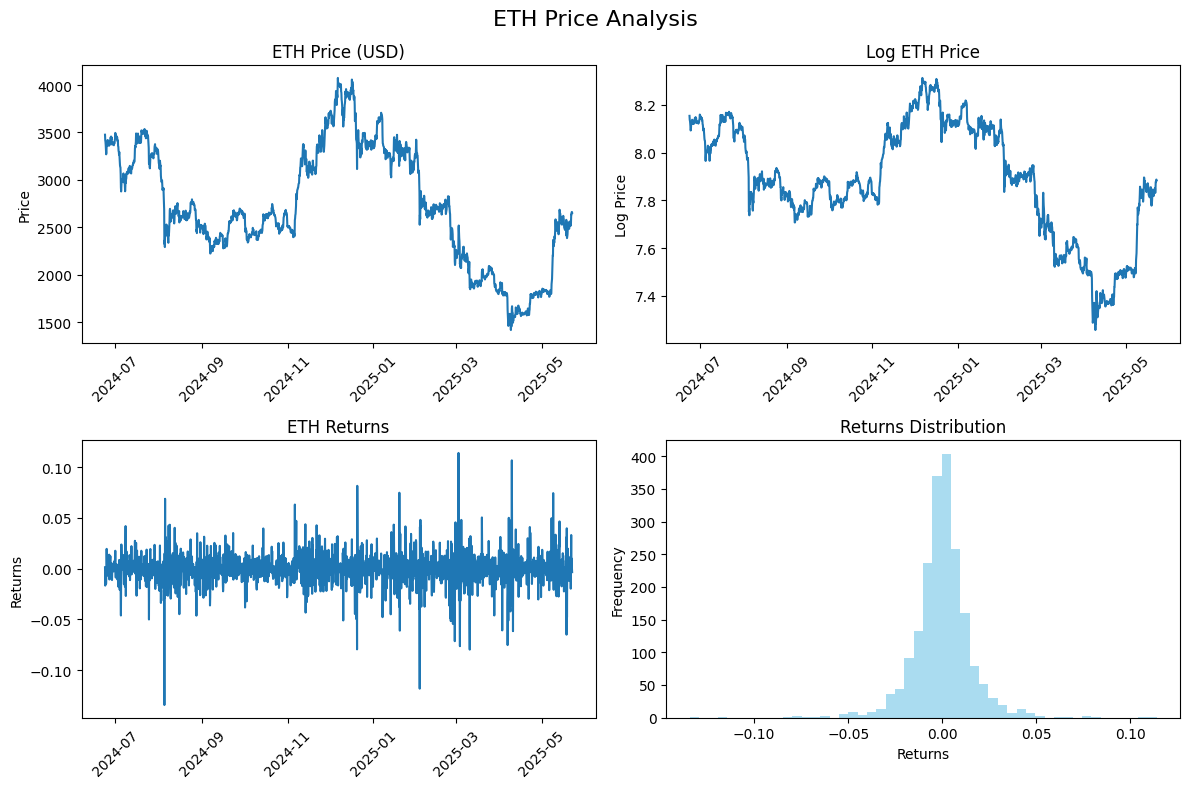

In [ ]:
def create_price_plots(df):
    """Create price-specific plots"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle('ETH Price Analysis', fontsize=16)

    # Price time series
    axes[0,0].plot(df.index, df['Close'])
    axes[0,0].set_title('ETH Price (USD)')
    axes[0,0].set_ylabel('Price')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Log price time series
    axes[0,1].plot(df.index, df['log_price'])
    axes[0,1].set_title('Log ETH Price')
    axes[0,1].set_ylabel('Log Price')
    axes[0,1].tick_params(axis='x', rotation=45)

    # Returns time series
    axes[1,0].plot(df.index, df['returns'])
    axes[1,0].set_title('ETH Returns')
    axes[1,0].set_ylabel('Returns')
    axes[1,0].tick_params(axis='x', rotation=45)

    # Returns distribution
    axes[1,1].hist(df['returns'].dropna(), bins=50, alpha=0.7, color='skyblue')
    axes[1,1].set_title('Returns Distribution')
    axes[1,1].set_xlabel('Returns')
    axes[1,1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

create_price_plots(edf)

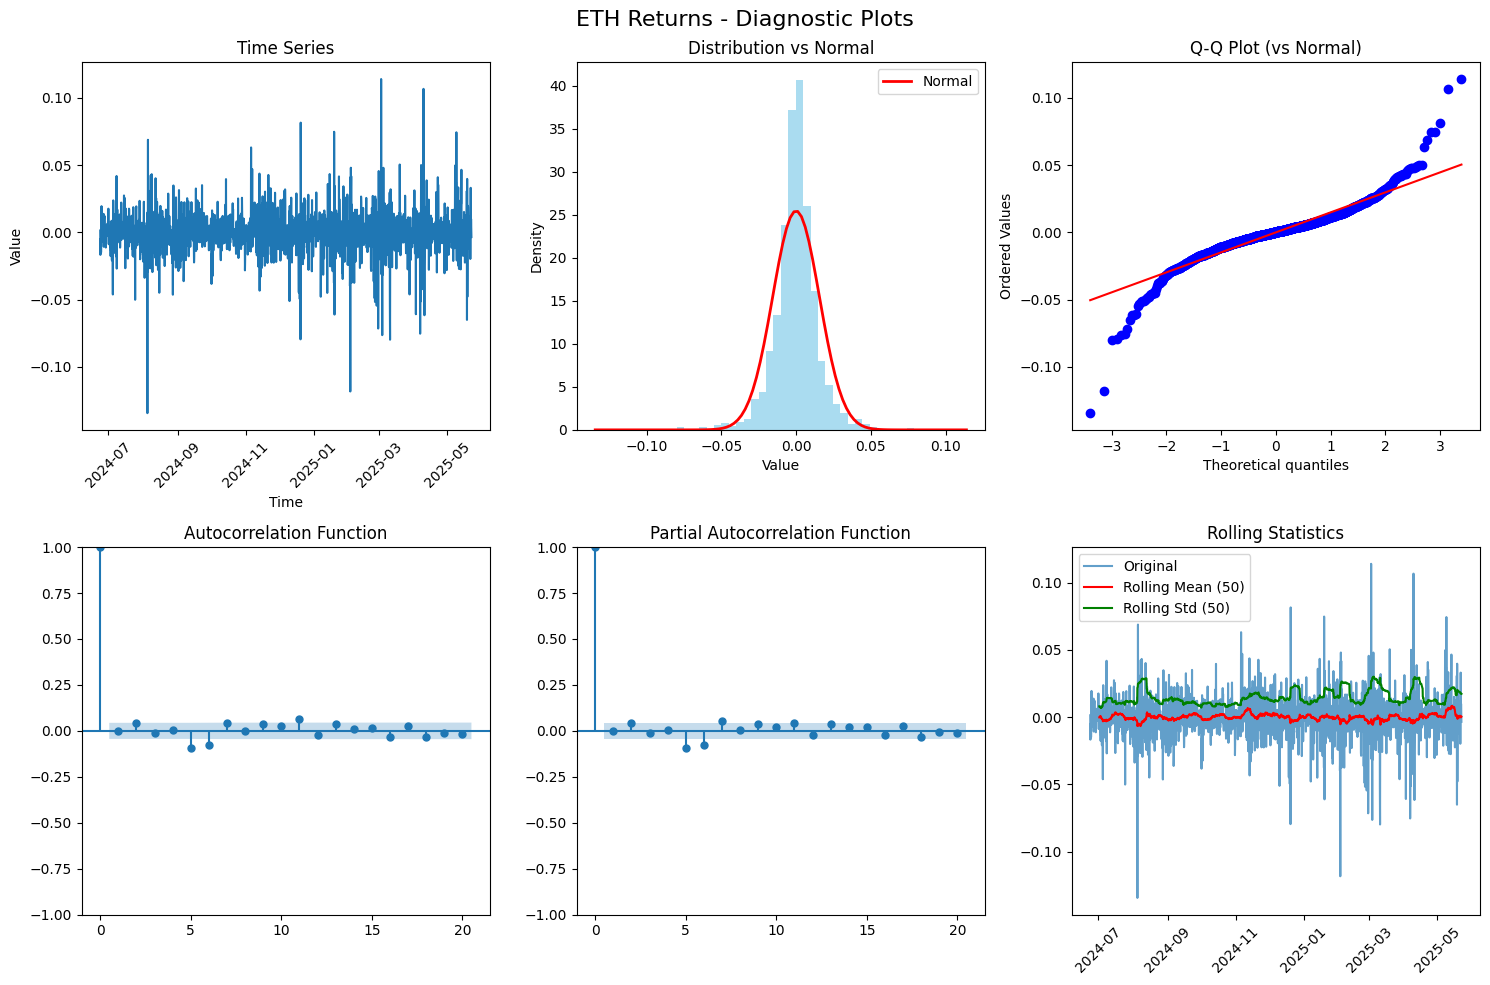

In [ ]:
def create_diagnostic_plots(series, name="Series"):
    """Create diagnostic plots for time series analysis"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'ETH {name} - Diagnostic Plots', fontsize=16)

    # Time series plot
    axes[0,0].plot(series.index, series)
    axes[0,0].set_title('Time Series')
    axes[0,0].set_xlabel('Time')
    axes[0,0].set_ylabel('Value')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Histogram with normal overlay
    axes[0,1].hist(series.dropna(), bins=50, density=True, alpha=0.7, color='skyblue')
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.min(), series.max(), 100)
    axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    axes[0,1].set_title('Distribution vs Normal')
    axes[0,1].legend()
    axes[0,1].set_xlabel('Value')
    axes[0,1].set_ylabel('Density')

    # Q-Q plot
    stats.probplot(series.dropna(), dist="norm", plot=axes[0,2])
    axes[0,2].set_title('Q-Q Plot (vs Normal)')

    # ACF plot
    try:
        sm.graphics.tsa.plot_acf(series.dropna(), ax=axes[1,0], lags=20)
        axes[1,0].set_title('Autocorrelation Function')
    except:
        axes[1,0].set_title('ACF - Error in calculation')

    # PACF plot
    try:
        sm.graphics.tsa.plot_pacf(series.dropna(), ax=axes[1,1], lags=20)
        axes[1,1].set_title('Partial Autocorrelation Function')
    except:
        axes[1,1].set_title('PACF - Error in calculation')

    # Rolling statistics
    rolling_mean = series.rolling(window=50).mean()
    rolling_std = series.rolling(window=50).std()
    axes[1,2].plot(series.index, series, alpha=0.7, label='Original')
    axes[1,2].plot(rolling_mean.index, rolling_mean, 'r-', label='Rolling Mean (50)')
    axes[1,2].plot(rolling_std.index, rolling_std, 'g-', label='Rolling Std (50)')
    axes[1,2].set_title('Rolling Statistics')
    axes[1,2].legend()
    axes[1,2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

create_diagnostic_plots(edf['returns'], 'Returns')

#Step 1B

In [ ]:
df1b = edf2k.copy()
df1b['returns'] = df1b['Close'].pct_change()
df1b['log_price'] = np.log(df1b['Close'])
df1b['log_returns'] = df1b['log_price'].diff()
df1b['first_diff'] = df1b['Close'].diff()
df1b['second_diff'] = df1b['first_diff'].diff()
df1b['log_first_diff'] = df1b['log_price'].diff()
df1b['log_second_diff'] = df1b['log_first_diff'].diff()
df1b.dropna(inplace=True)
df1b.head()

Price,Close,High,Low,Open,Volume,returns,log_price,log_returns,first_diff,second_diff,log_first_diff,log_second_diff
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD,,,,,,,
Datetime,,,,,,,,,,,,
2024-06-23 20:00:00+00:00,3418.294922,3477.653320,3408.583008,3477.653320,1652614656,-0.016724,8.136897,-0.016865,-58.139893,-62.947998,-0.016865,-0.018249
2024-06-24 00:00:00+00:00,3401.776367,3429.953857,3391.192383,3418.783203,1696828416,-0.004832,8.132053,-0.004844,-16.518555,41.621338,-0.004844,0.012021
2024-06-24 04:00:00+00:00,3368.948242,3410.029297,3355.392334,3400.775391,1960707072,-0.009650,8.122356,-0.009697,-32.828125,-16.309570,-0.009697,-0.004853
2024-06-24 08:00:00+00:00,3318.611328,3390.923584,3276.458740,3367.245850,3985838080,-0.014941,8.107302,-0.015054,-50.336914,-17.508789,-0.015054,-0.005357
2024-06-24 12:00:00+00:00,3269.865723,3334.960693,3262.663086,3319.010986,1661830144,-0.014689,8.092504,-0.014798,-48.745605,1.591309,-0.014798,0.000257


In [ ]:
#Same as ABOVE redoing all code:

In [ ]:
def adf_test_detailed(series, name):
    """Detailed ADF test with interpretation"""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{name}:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.6f}")

    if result[1] <= 0.01:
        conclusion = "Strongly Stationary (p ≤ 0.01)"
    elif result[1] <= 0.05:
        conclusion = "Stationary (p ≤ 0.05)"
    elif result[1] <= 0.10:
        conclusion = "Weakly Stationary (p ≤ 0.10)"
    else:
        conclusion = "Non-Stationary (p > 0.10)"

    print(f"  Conclusion: {conclusion}")
    return result[1] <= 0.05

# Test all transformations for stationarity
transformations = {
    'Original Price': df1b['Close'],
    'Log Price': df1b['log_price'],
    'First Difference': df1b['first_diff'],
    'Second Difference': df1b['second_diff'],
    'Returns (% change)': df1b['returns'],
    'Log Returns': df1b['log_returns'],
    'Log Second Difference': df1b['log_second_diff']
}

stationary_series = {}
for name, series in transformations.items():
    is_stationary = adf_test_detailed(series, name)
    if is_stationary:
        stationary_series[name] = series


Original Price:
  ADF Statistic: -1.821439
  p-value: 0.369871
  Critical Values:
    1%: -3.433655
    5%: -2.863000
    10%: -2.567547
  Conclusion: Non-Stationary (p > 0.10)

Log Price:
  ADF Statistic: -1.726430
  p-value: 0.417549
  Critical Values:
    1%: -3.433647
    5%: -2.862996
    10%: -2.567545
  Conclusion: Non-Stationary (p > 0.10)

First Difference:
  ADF Statistic: -17.562113
  p-value: 0.000000
  Critical Values:
    1%: -3.433639
    5%: -2.862993
    10%: -2.567543
  Conclusion: Strongly Stationary (p ≤ 0.01)

Second Difference:
  ADF Statistic: -14.480907
  p-value: 0.000000
  Critical Values:
    1%: -3.433672
    5%: -2.863008
    10%: -2.567551
  Conclusion: Strongly Stationary (p ≤ 0.01)

Returns (% change):
  ADF Statistic: -18.035565
  p-value: 0.000000
  Critical Values:
    1%: -3.433639
    5%: -2.862993
    10%: -2.567543
  Conclusion: Strongly Stationary (p ≤ 0.01)

Log Returns:
  ADF Statistic: -17.956334
  p-value: 0.000000
  Critical Values:
    1%:

##Plots

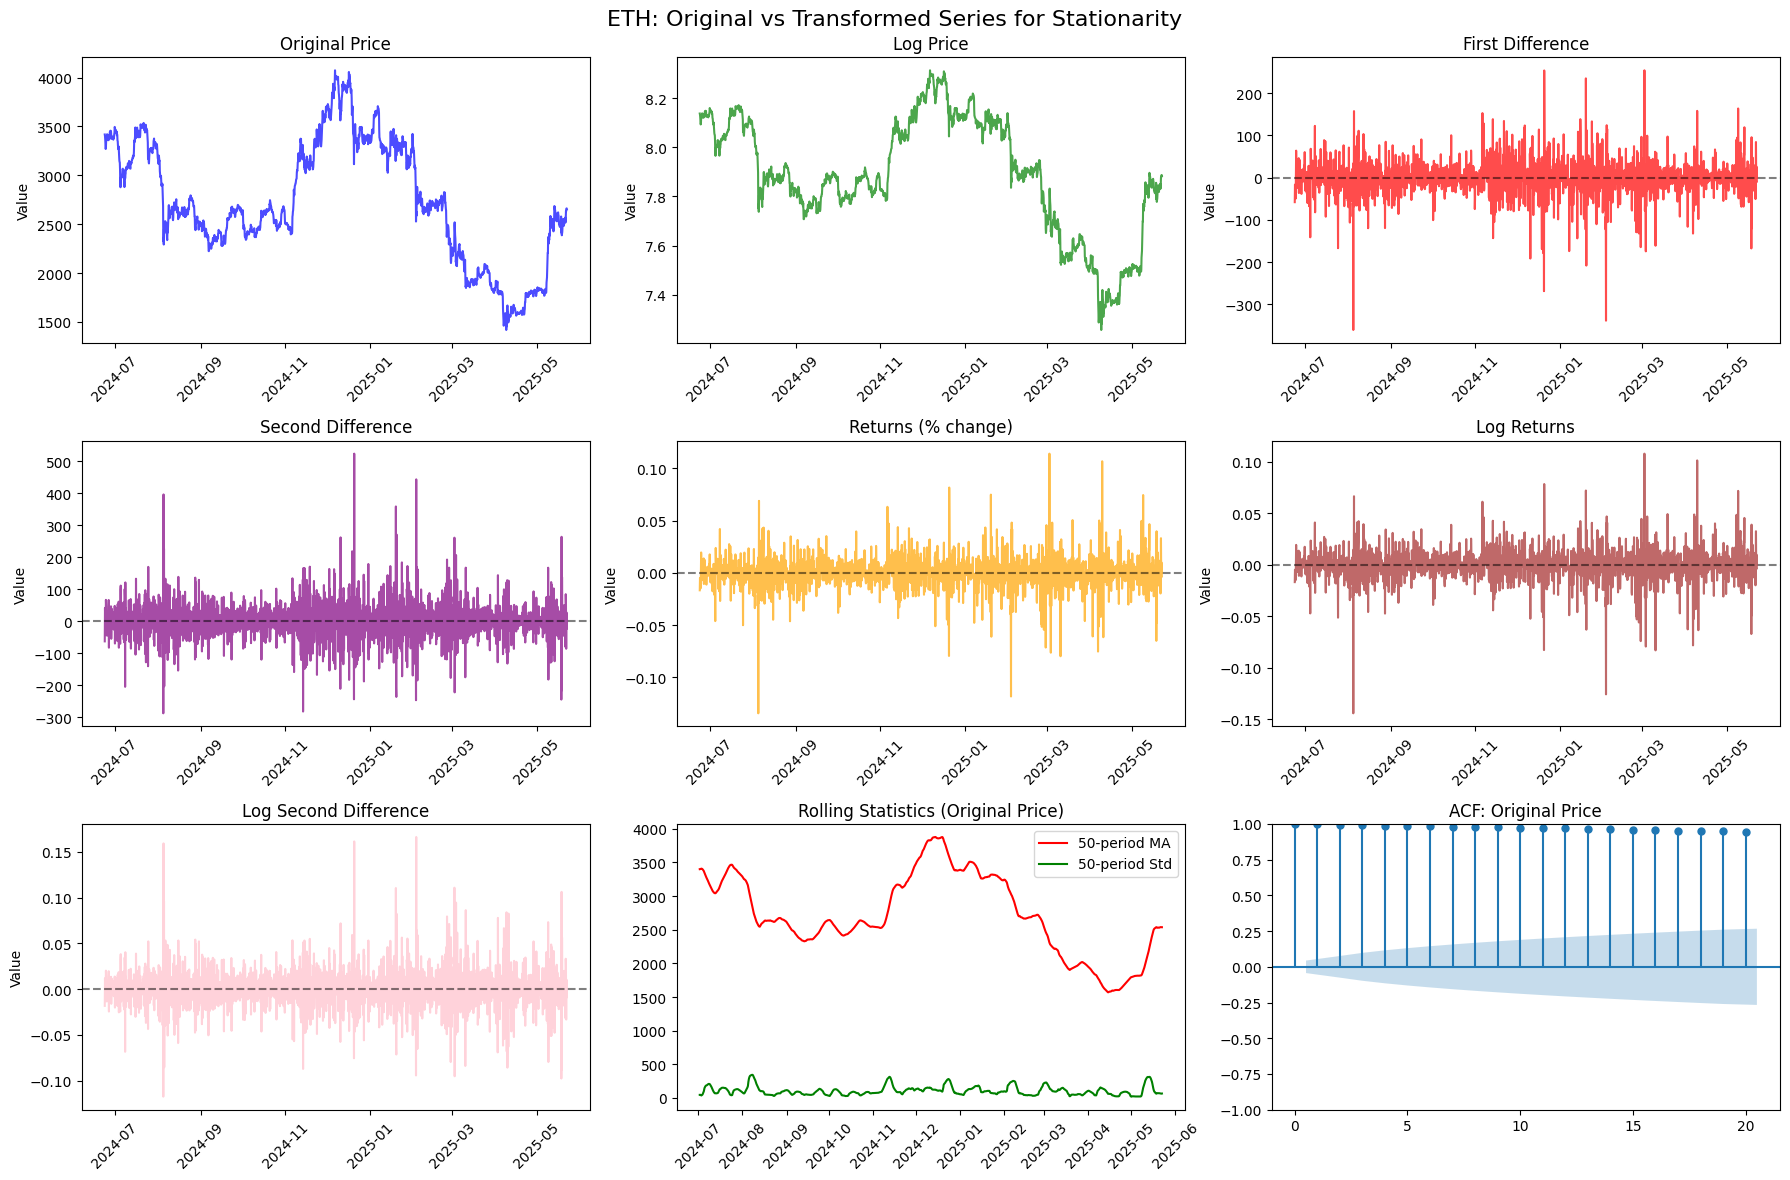

In [ ]:
def plot_transformations():
    """Plot all transformations to visualize stationarity"""
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    fig.suptitle('ETH: Original vs Transformed Series for Stationarity', fontsize=16)

    plot_configs = [
        ('Close', 'Original Price', axes[0,0], 'blue'),
        ('log_price', 'Log Price', axes[0,1], 'green'),
        ('first_diff', 'First Difference', axes[0,2], 'red'),
        ('second_diff', 'Second Difference', axes[1,0], 'purple'),
        ('returns', 'Returns (% change)', axes[1,1], 'orange'),
        ('log_returns', 'Log Returns', axes[1,2], 'brown'),
        ('log_second_diff', 'Log Second Difference', axes[2,0], 'pink')
    ]

    for col, title, ax, color in plot_configs:
        ax.plot(df1b.index, df1b[col], color=color, alpha=0.7)
        ax.set_title(f'{title}')
        ax.set_ylabel('Value')
        ax.tick_params(axis='x', rotation=45)

        # Add horizontal line at zero for differences and returns
        if 'diff' in col or 'returns' in col:
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)

    # Rolling statistics plot
    axes[2,1].plot(df1b.index, df1b['Close'].rolling(50).mean(), label='50-period MA', color='red')
    axes[2,1].plot(df1b.index, df1b['Close'].rolling(50).std(), label='50-period Std', color='green')
    axes[2,1].set_title('Rolling Statistics (Original Price)')
    axes[2,1].legend()
    axes[2,1].tick_params(axis='x', rotation=45)

    # ACF plot for original price
    try:
        sm.graphics.tsa.plot_acf(df1b['Close'].dropna(), ax=axes[2,2], lags=20)
        axes[2,2].set_title('ACF: Original Price')
    except:
        axes[2,2].set_title('ACF: Error in calculation')

    plt.tight_layout()
    plt.show()

plot_transformations()

##Choose Best


In [ ]:
stationary_preference = ['Log Returns', 'Returns (% change)', 'First Difference',
                        'Second Difference', 'Log Second Difference']

best_transformation = None
best_series = None

for pref in stationary_preference:
    if pref in stationary_series:
        best_transformation = pref
        best_series = stationary_series[pref]
        break

if best_transformation:
    print(f"Selected transformation: {best_transformation}")
    print(f"This series passes the ADF test for stationarity.")
else:
    print("No transformation achieved stationarity. Using log returns for analysis.")
    best_transformation = "Log Returns (Forced)"
    best_series = df1b['log_returns']

Selected transformation: Log Returns
This series passes the ADF test for stationarity.


##Descriptive Stats

In [ ]:
def enhanced_describe(series):
    """Enhanced descriptive statistics"""
    stats_dict = {
        'count': len(series),
        'mean': series.mean(),
        'median': series.median(),
        'std': series.std(),
        'var': series.var(),
        'min': series.min(),
        'max': series.max(),
        'range': series.max() - series.min(),
        'q25': series.quantile(0.25),
        'q50': series.quantile(0.50),
        'q75': series.quantile(0.75),
        'iqr': series.quantile(0.75) - series.quantile(0.25),
        'skewness': stats.skew(series.dropna()),
        'kurtosis': stats.kurtosis(series.dropna()),
        'cv': series.std() / series.mean() if series.mean() != 0 else np.nan,
    }
    return pd.Series(stats_dict)

print(f"Enhanced Statistics for {best_transformation}:")
print(enhanced_describe(best_series))

Enhanced Statistics for Log Returns:
count       1998.000000
mean          -0.000135
median         0.000226
std            0.015746
var            0.000248
min           -0.144343
max            0.107958
range          0.252301
q25           -0.006892
q50            0.000226
q75            0.007000
iqr            0.013892
skewness      -0.635224
kurtosis      10.540425
cv          -116.334870
dtype: float64


##Distribution and Persistance


In [ ]:
def distribution_analysis(series, name="Series"):
    """Comprehensive distribution analysis"""
    print(f"\n{name} Distribution Analysis:")

    try:
        # Jarque-Bera (good for financial data)
        jb_stat, jb_p = stats.jarque_bera(series.dropna())
        print(f"Jarque-Bera Test: statistic={jb_stat:.4f}, p-value={jb_p:.4f}")
        print(f"Normality (JB): {'Reject' if jb_p < 0.05 else 'Accept'} null hypothesis of normality")

        # Shapiro-Wilk (if sample size allows)
        if len(series) <= 5000:
            shapiro_stat, shapiro_p = stats.shapiro(series.dropna())
            print(f"Shapiro-Wilk Test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    except Exception as e:
        print(f"Error in normality tests: {e}")

    # Distribution parameters
    print(f"Skewness: {stats.skew(series.dropna()):.4f}")
    print(f"Excess Kurtosis: {stats.kurtosis(series.dropna()):.4f}")

distribution_analysis(best_series, best_transformation)

# Persistence analysis
def persistence_analysis(series, name="Series", max_lags=20):
    """Analyze persistence and autocorrelation"""
    print(f"\n{name} Persistence Analysis:")

    try:
        # ACF analysis
        acf_values, acf_confint = acf(series.dropna(), nlags=max_lags, alpha=0.05)
        print(f"ACF at lag 1: {acf_values[1]:.4f}")
        print(f"ACF at lag 5: {acf_values[5]:.4f}")
        print(f"ACF at lag 10: {acf_values[10]:.4f}")

        # PACF analysis
        pacf_values, pacf_confint = pacf(series.dropna(), nlags=max_lags, alpha=0.05)
        print(f"PACF at lag 1: {pacf_values[1]:.4f}")

        # Ljung-Box Test
        lb_test = acorr_ljungbox(series.dropna(), lags=10, return_df=True)
        print(f"Ljung-Box Test (lag 10): statistic={lb_test['lb_stat'].iloc[-1]:.4f}, "
              f"p-value={lb_test['lb_pvalue'].iloc[-1]:.4f}")
        print(f"Serial Correlation: {'Present' if lb_test['lb_pvalue'].iloc[-1] < 0.05 else 'Not detected'}")

        # Half-life calculation
        if abs(acf_values[1]) < 1 and acf_values[1] != 0:
            half_life = np.log(0.5) / np.log(abs(acf_values[1]))
            print(f"Half-life of shocks: {half_life:.2f} periods")

    except Exception as e:
        print(f"Error in persistence analysis: {e}")

persistence_analysis(best_series, best_transformation)



Log Returns Distribution Analysis:
Jarque-Bera Test: statistic=9383.4910, p-value=0.0000
Normality (JB): Reject null hypothesis of normality
Shapiro-Wilk Test: statistic=0.8950, p-value=0.0000
Skewness: -0.6352
Excess Kurtosis: 10.5404

Log Returns Persistence Analysis:
ACF at lag 1: 0.0002
ACF at lag 5: -0.0936
ACF at lag 10: 0.0258
PACF at lag 1: 0.0002
Ljung-Box Test (lag 10): statistic=41.7940, p-value=0.0000
Serial Correlation: Present
Half-life of shocks: 0.08 periods


##Volatility Analysis

In [ ]:
def volatility_analysis(series, name, window=30):
    """Analyze volatility characteristics"""
    print(f"\n{name} Volatility Analysis:")

    # Only do volatility analysis if series resembles returns
    if 'returns' in name.lower() or 'diff' in name.lower():
        # Rolling volatility
        rolling_vol = series.rolling(window=window).std()
        print(f"Mean Rolling Volatility ({window} periods): {rolling_vol.mean():.6f}")
        print(f"Volatility of Volatility: {rolling_vol.std():.6f}")

        # Volatility clustering
        squared_series = series ** 2
        try:
            acf_squared = acf(squared_series.dropna(), nlags=1)[1]
            print(f"Volatility Clustering (ACF of squared series): {acf_squared:.4f}")
        except:
            print("Could not calculate volatility clustering")

        # Risk metrics
        var_95 = series.quantile(0.05)
        var_99 = series.quantile(0.01)
        print(f"Value at Risk (95%): {var_95:.6f}")
        print(f"Value at Risk (99%): {var_99:.6f}")

        # Expected Shortfall
        es_95 = series[series <= var_95].mean() if any(series <= var_95) else np.nan
        es_99 = series[series <= var_99].mean() if any(series <= var_99) else np.nan
        print(f"Expected Shortfall (95%): {es_95:.6f}")
        print(f"Expected Shortfall (99%): {es_99:.6f}")

        # Annualized measures (if returns)
        if 'returns' in name.lower():
            annualized_vol = series.std() * np.sqrt(24 * 365)
            annualized_return = series.mean() * 24 * 365
            sharpe_ratio = annualized_return / annualized_vol if annualized_vol != 0 else np.nan
            print(f"Annualized Return: {annualized_return:.2%}")
            print(f"Annualized Volatility: {annualized_vol:.2%}")
            print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

volatility_analysis(best_series, best_transformation)


Log Returns Volatility Analysis:
Mean Rolling Volatility (30 periods): 0.014431
Volatility of Volatility: 0.006339
Volatility Clustering (ACF of squared series): 0.1059
Value at Risk (95%): -0.023348
Value at Risk (99%): -0.049024
Expected Shortfall (95%): -0.038934
Expected Shortfall (99%): -0.069774
Annualized Return: -118.57%
Annualized Volatility: 147.38%
Sharpe Ratio: -0.8045


##Comparison Graphs

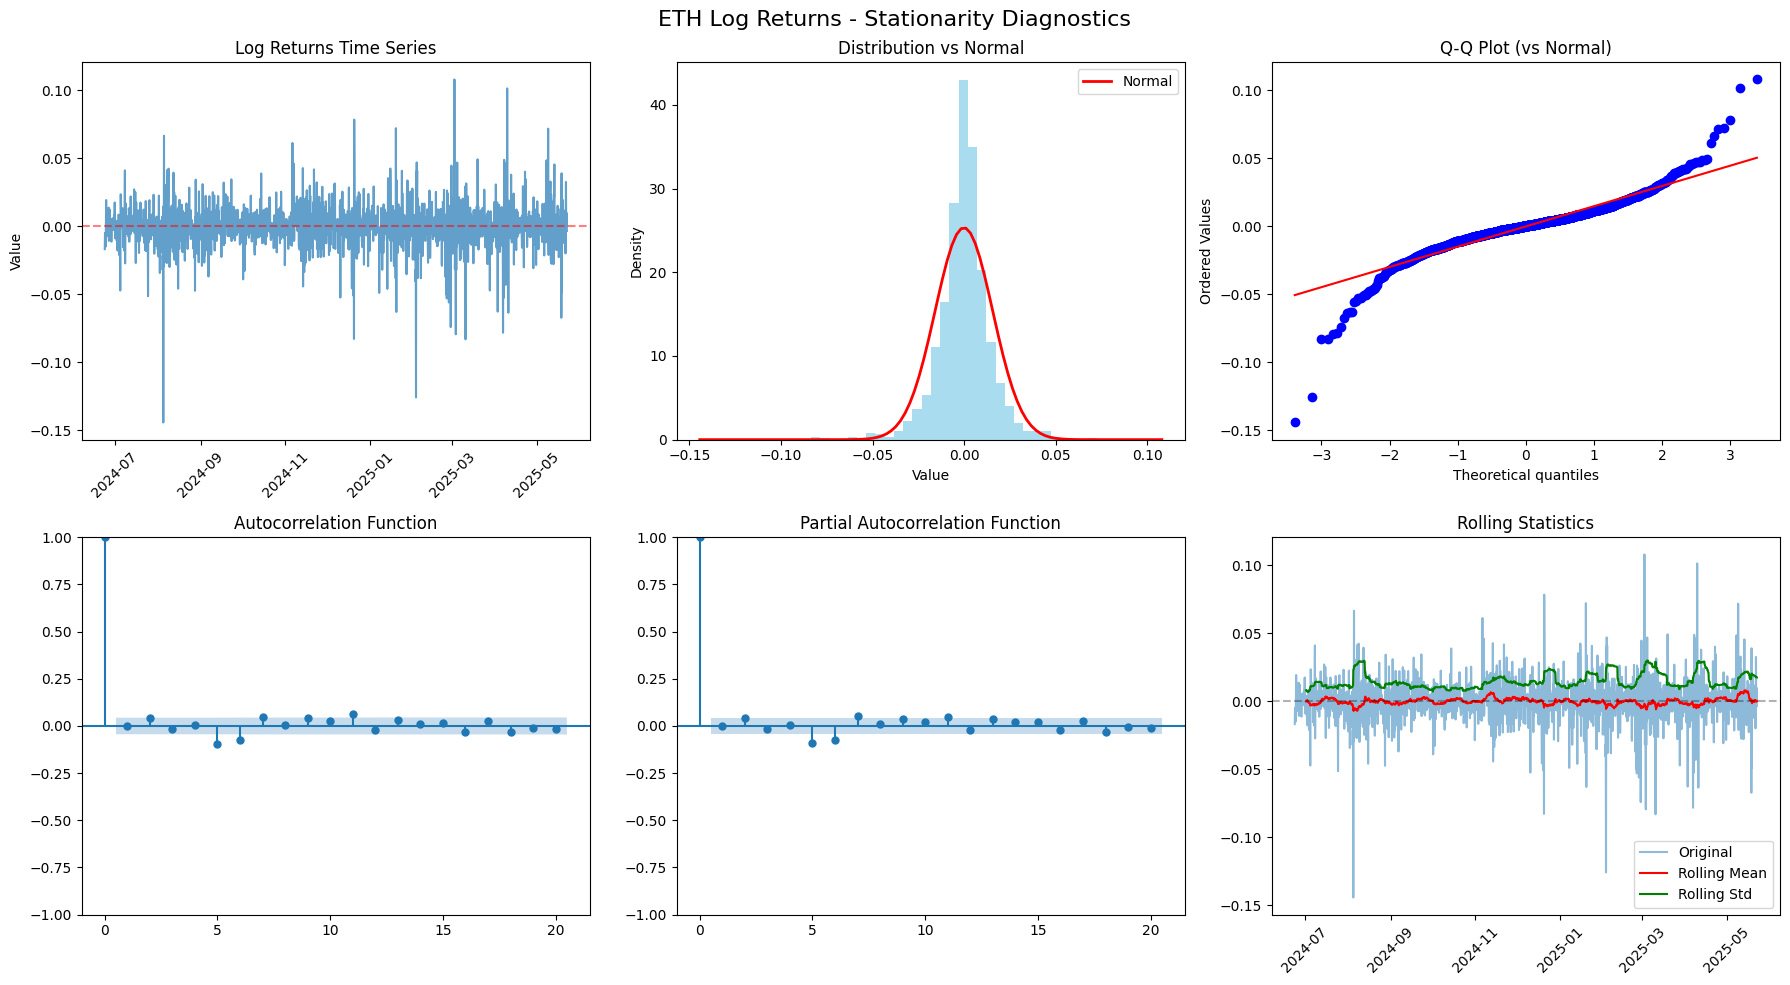

In [ ]:
def create_stationary_diagnostics(series, name):
    """Create comprehensive diagnostic plots for stationary series"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'ETH {name} - Stationarity Diagnostics', fontsize=16)

    # Time series plot
    axes[0,0].plot(series.index, series, alpha=0.7)
    axes[0,0].set_title(f'{name} Time Series')
    axes[0,0].set_ylabel('Value')
    axes[0,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[0,0].tick_params(axis='x', rotation=45)

    # Distribution histogram
    axes[0,1].hist(series.dropna(), bins=50, density=True, alpha=0.7, color='skyblue')
    mu, sigma = series.mean(), series.std()
    x = np.linspace(series.min(), series.max(), 100)
    axes[0,1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
    axes[0,1].set_title('Distribution vs Normal')
    axes[0,1].legend()
    axes[0,1].set_xlabel('Value')
    axes[0,1].set_ylabel('Density')

    # Q-Q plot
    stats.probplot(series.dropna(), dist="norm", plot=axes[0,2])
    axes[0,2].set_title('Q-Q Plot (vs Normal)')

    # ACF plot
    try:
        sm.graphics.tsa.plot_acf(series.dropna(), ax=axes[1,0], lags=20)
        axes[1,0].set_title('Autocorrelation Function')
    except:
        axes[1,0].set_title('ACF - Error')

    # PACF plot
    try:
        sm.graphics.tsa.plot_pacf(series.dropna(), ax=axes[1,1], lags=20)
        axes[1,1].set_title('Partial Autocorrelation Function')
    except:
        axes[1,1].set_title('PACF - Error')

    # Rolling statistics
    rolling_mean = series.rolling(window=50).mean()
    rolling_std = series.rolling(window=50).std()
    axes[1,2].plot(series.index, series, alpha=0.5, label='Original')
    axes[1,2].plot(rolling_mean.index, rolling_mean, 'r-', label='Rolling Mean')
    axes[1,2].plot(rolling_std.index, rolling_std, 'g-', label='Rolling Std')
    axes[1,2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
    axes[1,2].set_title('Rolling Statistics')
    axes[1,2].legend()
    axes[1,2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

create_stationary_diagnostics(best_series, best_transformation)

#Step 1 C

## Clean Data and Get ready

In [ ]:
fdf = edf2k.copy()
fdf['returns'] = fdf['Close'].pct_change()
fdf['log_price'] = np.log(fdf['Close'])
fdf['log_returns'] = fdf['log_price'].diff()
prices = fdf['Close'].values
log_prices = np.log(prices)

In [ ]:
def get_weights(d, num_k):
    w = np.zeros(num_k)
    w[0] = 1.0

    for k in range(1, num_k):
        w[k] = -w[k-1] * (d - k + 1) / k

    return w

In [ ]:
def frac_diff(x, d, floor=1e-3):
#Fractional difficulty
    # Convert to numpy array
    x = np.array(x)
    n = len(x)

    # Get weights
    weights = get_weights(d, n)

    # Apply floor threshold to weights
    weights = weights[np.abs(weights) >= floor]
    width = len(weights)

    # Initialize output array
    output = np.full(n, np.nan)

    # Apply fractional differencing
    for i in range(width, n):
        output[i] = np.dot(weights, x[i-width+1:i+1][::-1])

    return output

In [ ]:
def find_optimal_d(prices, d_range=np.arange(0.1, 1.0, 0.1), max_corr_loss=0.05):
#finding the optimal fractional differencing parameter
    results = {}

    for d in d_range:
        # Apply fractional differencing
        frac_diff_series = frac_diff(prices, d)

        # Remove NaN values
        valid_frac = frac_diff_series[~np.isnan(frac_diff_series)]

        # Ensure valid_orig is also 1D and matches the length of valid_frac
        # Slice the original prices array and flatten it
        valid_orig = prices[-len(valid_frac):].flatten()

        if len(valid_frac) > 50 and len(valid_orig) == len(valid_frac):  # Minimum observations for tests and ensure lengths match
            # ADF test for stationarity
            adf_result = adfuller(valid_frac, autolag='AIC')
            adf_pvalue = adf_result[1]
            is_stationary = adf_pvalue <= 0.05

            # Correlation with original series
            correlation = np.corrcoef(valid_orig, valid_frac)[0, 1]

            results[d] = {
                'adf_pvalue': adf_pvalue,
                'is_stationary': is_stationary,
                'correlation': correlation,
                'n_observations': len(valid_frac)
            }

    # Find optimal d: lowest d that achieves stationarity
    optimal_d = None
    # Filter out results where stationarity wasn't checked or failed due to length mismatch
    stationary_results = {d: res for d, res in results.items() if res['is_stationary']}

    if stationary_results:
        optimal_d = min(stationary_results.keys())
    else:
        # If no d achieves stationarity, choose the one with lowest p-value among those checked
        if results:
             optimal_d = min(results.keys(), key=lambda x: results[x]['adf_pvalue'])
        else:
             # Handle case where no valid results were generated
             print("Warning: No valid 'd' values found for stationarity testing.")
             return None, results

    return optimal_d, results

## Find the optimal Frac Diff parameter

Results for Price Levels:
Optimal d: 0.300
ADF p-value: 0.033257
Correlation with original: 0.9363

Results for Log Prices:
Optimal d: 0.300
ADF p-value: 0.046731
Correlation with original: 0.9389


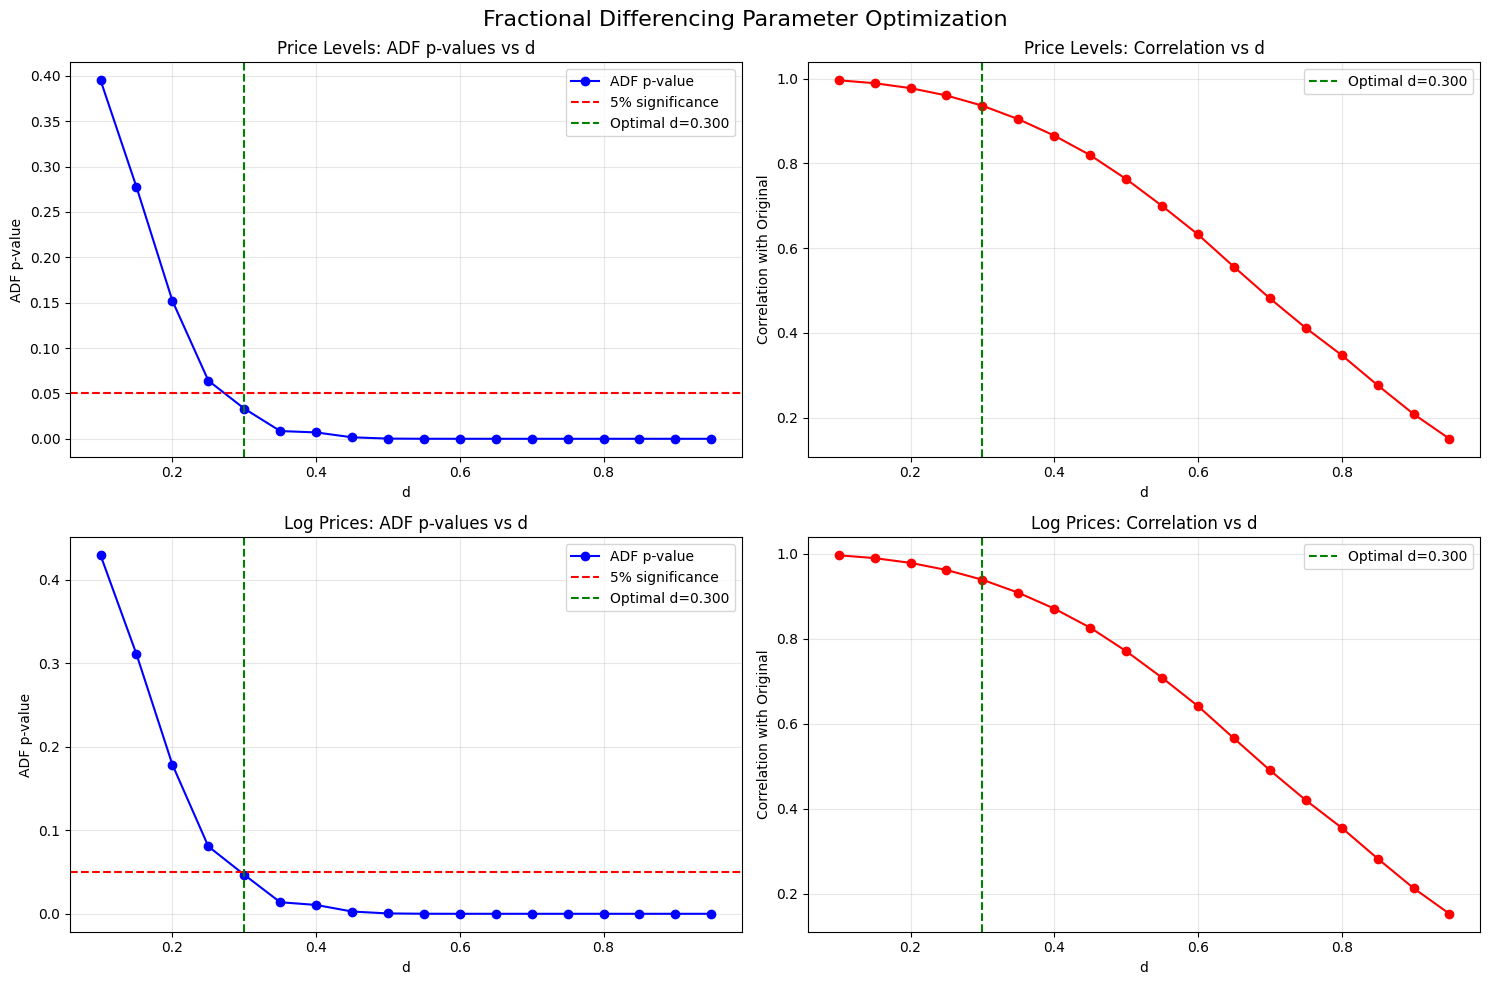

In [ ]:
# Test different d values
d_range = np.arange(0.1, 1.0, 0.05)
optimal_d_prices, results_prices = find_optimal_d(prices, d_range)
optimal_d_log, results_log = find_optimal_d(log_prices, d_range)

print("Results for Price Levels:")
print(f"Optimal d: {optimal_d_prices:.3f}")
print(f"ADF p-value: {results_prices[optimal_d_prices]['adf_pvalue']:.6f}")
print(f"Correlation with original: {results_prices[optimal_d_prices]['correlation']:.4f}")

print("\nResults for Log Prices:")
print(f"Optimal d: {optimal_d_log:.3f}")
print(f"ADF p-value: {results_log[optimal_d_log]['adf_pvalue']:.6f}")
print(f"Correlation with original: {results_log[optimal_d_log]['correlation']:.4f}")

# Visualize the optimization process
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Fractional Differencing Parameter Optimization', fontsize=16)

# ADF p-values for price levels
d_values = list(results_prices.keys())
adf_pvalues_prices = [results_prices[d]['adf_pvalue'] for d in d_values]
correlations_prices = [results_prices[d]['correlation'] for d in d_values]

ax1.plot(d_values, adf_pvalues_prices, 'bo-', label='ADF p-value')
ax1.axhline(y=0.05, color='red', linestyle='--', label='5% significance')
ax1.axvline(x=optimal_d_prices, color='green', linestyle='--', label=f'Optimal d={optimal_d_prices:.3f}')
ax1.set_xlabel('d')
ax1.set_ylabel('ADF p-value')
ax1.set_title('Price Levels: ADF p-values vs d')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation for price levels
ax2.plot(d_values, correlations_prices, 'ro-')
ax2.axvline(x=optimal_d_prices, color='green', linestyle='--', label=f'Optimal d={optimal_d_prices:.3f}')
ax2.set_xlabel('d')
ax2.set_ylabel('Correlation with Original')
ax2.set_title('Price Levels: Correlation vs d')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ADF p-values for log prices
d_values_log = list(results_log.keys())
adf_pvalues_log = [results_log[d]['adf_pvalue'] for d in d_values_log]
correlations_log = [results_log[d]['correlation'] for d in d_values_log]

ax3.plot(d_values_log, adf_pvalues_log, 'bo-', label='ADF p-value')
ax3.axhline(y=0.05, color='red', linestyle='--', label='5% significance')
ax3.axvline(x=optimal_d_log, color='green', linestyle='--', label=f'Optimal d={optimal_d_log:.3f}')
ax3.set_xlabel('d')
ax3.set_ylabel('ADF p-value')
ax3.set_title('Log Prices: ADF p-values vs d')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Correlation for log prices
ax4.plot(d_values_log, correlations_log, 'ro-')
ax4.axvline(x=optimal_d_log, color='green', linestyle='--', label=f'Optimal d={optimal_d_log:.3f}')
ax4.set_xlabel('d')
ax4.set_ylabel('Correlation with Original')
ax4.set_title('Log Prices: Correlation vs d')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Apply fractional differencing with optimal parameters
frac_diff_prices = frac_diff(prices.flatten(), optimal_d_prices) # Ensure input to frac_diff is 1D
frac_diff_log_prices = frac_diff(log_prices.flatten(), optimal_d_log) # Ensure input to frac_diff is 1D

# Create DataFrame for analysis
fdf1 = pd.DataFrame({
    # Ensure prices and log_prices are 1-dimensional
    'prices': prices.flatten(),
    'log_prices': log_prices.flatten(),
    'frac_diff_prices': frac_diff_prices,
    'frac_diff_log_prices': frac_diff_log_prices
}, index=edf2k.index) # Use the index from edf2k

# Add traditional transformations for comparison
fdf1['returns'] = fdf1['prices'].pct_change()
fdf1['log_returns'] = fdf1['log_prices'].diff()
fdf1['first_diff'] = fdf1['prices'].diff()

print("Created fractionally differenced series:")
print(f"Fractional diff prices (d={optimal_d_prices:.3f}): {(~fdf1['frac_diff_prices'].isna()).sum()} valid observations")
print(f"Fractional diff log prices (d={optimal_d_log:.3f}): {(~fdf1['frac_diff_log_prices'].isna()).sum()} valid observations")

Created fractionally differenced series:
Fractional diff prices (d=0.300): 1934 valid observations
Fractional diff log prices (d=0.300): 1934 valid observations


## Descriptive Stats

In [ ]:
def enhanced_describe(series):
    """Enhanced descriptive statistics"""
    clean_series = series.dropna()
    stats_dict = {
        'count': len(clean_series),
        'mean': clean_series.mean(),
        'median': clean_series.median(),
        'std': clean_series.std(),
        'var': clean_series.var(),
        'min': clean_series.min(),
        'max': clean_series.max(),
        'range': clean_series.max() - clean_series.min(),
        'q25': clean_series.quantile(0.25),
        'q50': clean_series.quantile(0.50),
        'q75': clean_series.quantile(0.75),
        'iqr': clean_series.quantile(0.75) - clean_series.quantile(0.25),
        'skewness': stats.skew(clean_series),
        'kurtosis': stats.kurtosis(clean_series),
        'cv': clean_series.std() / clean_series.mean() if clean_series.mean() != 0 else np.nan,
    }
    return pd.Series(stats_dict)

In [ ]:
frac_diff_prices_desc = enhanced_describe(fdf1['frac_diff_prices'])
print(frac_diff_prices_desc)


count        1934.000000
mean          592.086830
median        585.930657
std           151.596014
var         22981.351607
min           100.035759
max          1052.099605
range         952.063846
q25           486.665334
q50           585.930657
q75           704.281309
iqr           217.615975
skewness        0.133078
kurtosis       -0.466925
cv              0.256037
dtype: float64


In [ ]:
frac_diff_log_desc = enhanced_describe(fdf1['frac_diff_log_prices'])
print(frac_diff_log_desc)

count       1934.000000
mean           1.730680
median         1.735216
std            0.058303
var            0.003399
min            1.504695
max            1.867349
range          0.362654
q25            1.694969
q50            1.735216
q75            1.775610
iqr            0.080641
skewness      -0.408035
kurtosis      -0.186959
cv             0.033688
dtype: float64


## Stationarity Tests


In [ ]:
def stationarity_tests(series, name="Series"):
    """Comprehensive stationarity testing"""
    clean_series = series.dropna()
    print(f"\n{name} Stationarity Tests:")

    # ADF Test
    try:
        adf_result = adfuller(clean_series, autolag='AIC')
        print(f"ADF Test: statistic={adf_result[0]:.4f}, p-value={adf_result[1]:.6f}")
        print(f"ADF Critical Values: {adf_result[4]}")
        print(f"ADF Conclusion: {'Stationary' if adf_result[1] < 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"ADF Test Error: {e}")

    # KPSS Test
    try:
        kpss_result = kpss(clean_series, regression='c', nlags='auto')
        print(f"KPSS Test: statistic={kpss_result[0]:.4f}, p-value={kpss_result[1]:.6f}")
        print(f"KPSS Critical Values: {kpss_result[3]}")
        print(f"KPSS Conclusion: {'Stationary' if kpss_result[1] > 0.05 else 'Non-stationary'}")
    except Exception as e:
        print(f"KPSS Test Error: {e}")

# Test all series for comparison
stationarity_tests(fdf1['prices'], "Original Prices")
stationarity_tests(fdf1['log_prices'], "Log Prices")
stationarity_tests(fdf1['frac_diff_prices'], f"Frac Diff Prices (d={optimal_d_prices:.3f})")
stationarity_tests(fdf1['frac_diff_log_prices'], f"Frac Diff Log Prices (d={optimal_d_log:.3f})")
stationarity_tests(fdf1['returns'], "Returns")
stationarity_tests(fdf1['log_returns'], "Log Returns")


Original Prices Stationarity Tests:
ADF Test: statistic=-1.8417, p-value=0.359956
ADF Critical Values: {'1%': np.float64(-3.4336519592295947), '5%': np.float64(-2.862998620943585), '10%': np.float64(-2.567546508593341)}
ADF Conclusion: Non-stationary
KPSS Test: statistic=2.0057, p-value=0.010000
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
KPSS Conclusion: Non-stationary

Log Prices Stationarity Tests:
ADF Test: statistic=-1.6988, p-value=0.431720
ADF Critical Values: {'1%': np.float64(-3.433643643742798), '5%': np.float64(-2.862994949652858), '10%': np.float64(-2.5675445538118042)}
ADF Conclusion: Non-stationary
KPSS Test: statistic=2.2798, p-value=0.010000
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
KPSS Conclusion: Non-stationary

Frac Diff Prices (d=0.300) Stationarity Tests:
ADF Test: statistic=-3.0179, p-value=0.033257
ADF Critical Values: {'1%': np.float64(-3.433751579966644), '5%': np.float64(-2.863042602745826

## Distribution tests & Persistance

In [ ]:
def distribution_analysis(series, name="Series"):
    """Comprehensive distribution analysis"""
    clean_series = series.dropna()
    print(f"\n{name} Distribution Analysis:")

    try:
        # Jarque-Bera test
        jb_stat, jb_p = stats.jarque_bera(clean_series)
        print(f"Jarque-Bera Test: statistic={jb_stat:.4f}, p-value={jb_p:.6f}")
        print(f"Normality (JB): {'Reject' if jb_p < 0.05 else 'Accept'} null hypothesis")

        # Shapiro-Wilk (if small enough sample)
        if len(clean_series) <= 5000:
            shapiro_stat, shapiro_p = stats.shapiro(clean_series)
            print(f"Shapiro-Wilk Test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")

        # Distribution parameters
        print(f"Skewness: {stats.skew(clean_series):.4f}")
        print(f"Excess Kurtosis: {stats.kurtosis(clean_series):.4f}")

    except Exception as e:
        print(f"Error in distribution tests: {e}")

distribution_analysis(fdf1['frac_diff_prices'], f"Frac Diff Prices (d={optimal_d_prices:.3f})")
distribution_analysis(fdf1['frac_diff_log_prices'], f"Frac Diff Log Prices (d={optimal_d_log:.3f})")

def persistence_analysis(series, name="Series", max_lags=20):
    """Analyze persistence and autocorrelation"""
    clean_series = series.dropna()
    print(f"\n{name} Persistence Analysis:")

    try:
        # ACF analysis
        acf_values, acf_confint = acf(clean_series, nlags=max_lags, alpha=0.05)
        print(f"ACF at lag 1: {acf_values[1]:.4f}")
        print(f"ACF at lag 5: {acf_values[5]:.4f}")
        print(f"ACF at lag 10: {acf_values[10]:.4f}")

        # PACF analysis
        pacf_values, pacf_confint = pacf(clean_series, nlags=max_lags, alpha=0.05)
        print(f"PACF at lag 1: {pacf_values[1]:.4f}")

        # Ljung-Box Test
        lb_test = acorr_ljungbox(clean_series, lags=10, return_df=True)
        print(f"Ljung-Box Test (lag 10): statistic={lb_test['lb_stat'].iloc[-1]:.4f}, "
              f"p-value={lb_test['lb_pvalue'].iloc[-1]:.6f}")
        print(f"Serial Correlation: {'Present' if lb_test['lb_pvalue'].iloc[-1] < 0.05 else 'Not detected'}")

        # Half-life calculation
        if abs(acf_values[1]) < 1 and acf_values[1] != 0:
            half_life = np.log(0.5) / np.log(abs(acf_values[1]))
            print(f"Half-life of shocks: {half_life:.2f} periods")

    except Exception as e:
        print(f"Error in persistence analysis: {e}")

persistence_analysis(fdf1['frac_diff_prices'], f"Frac Diff Prices (d={optimal_d_prices:.3f})")
persistence_analysis(fdf1['frac_diff_log_prices'], f"Frac Diff Log Prices (d={optimal_d_log:.3f})")



Frac Diff Prices (d=0.300) Distribution Analysis:
Jarque-Bera Test: statistic=23.2771, p-value=0.000009
Normality (JB): Reject null hypothesis
Shapiro-Wilk Test: statistic=0.9925, p-value=0.000000
Skewness: 0.1331
Excess Kurtosis: -0.4669

Frac Diff Log Prices (d=0.300) Distribution Analysis:
Jarque-Bera Test: statistic=56.4827, p-value=0.000000
Normality (JB): Reject null hypothesis
Shapiro-Wilk Test: statistic=0.9838, p-value=0.000000
Skewness: -0.4080
Excess Kurtosis: -0.1870

Frac Diff Prices (d=0.300) Persistence Analysis:
ACF at lag 1: 0.9559
ACF at lag 5: 0.8847
ACF at lag 10: 0.8559
PACF at lag 1: 0.9564
Ljung-Box Test (lag 10): statistic=15491.9008, p-value=0.000000
Serial Correlation: Present
Half-life of shocks: 15.37 periods

Frac Diff Log Prices (d=0.300) Persistence Analysis:
ACF at lag 1: 0.9587
ACF at lag 5: 0.8864
ACF at lag 10: 0.8640
PACF at lag 1: 0.9592
Ljung-Box Test (lag 10): statistic=15625.5271, p-value=0.000000
Serial Correlation: Present
Half-life of shocks:

## VOlatility Analysis

## Graphs

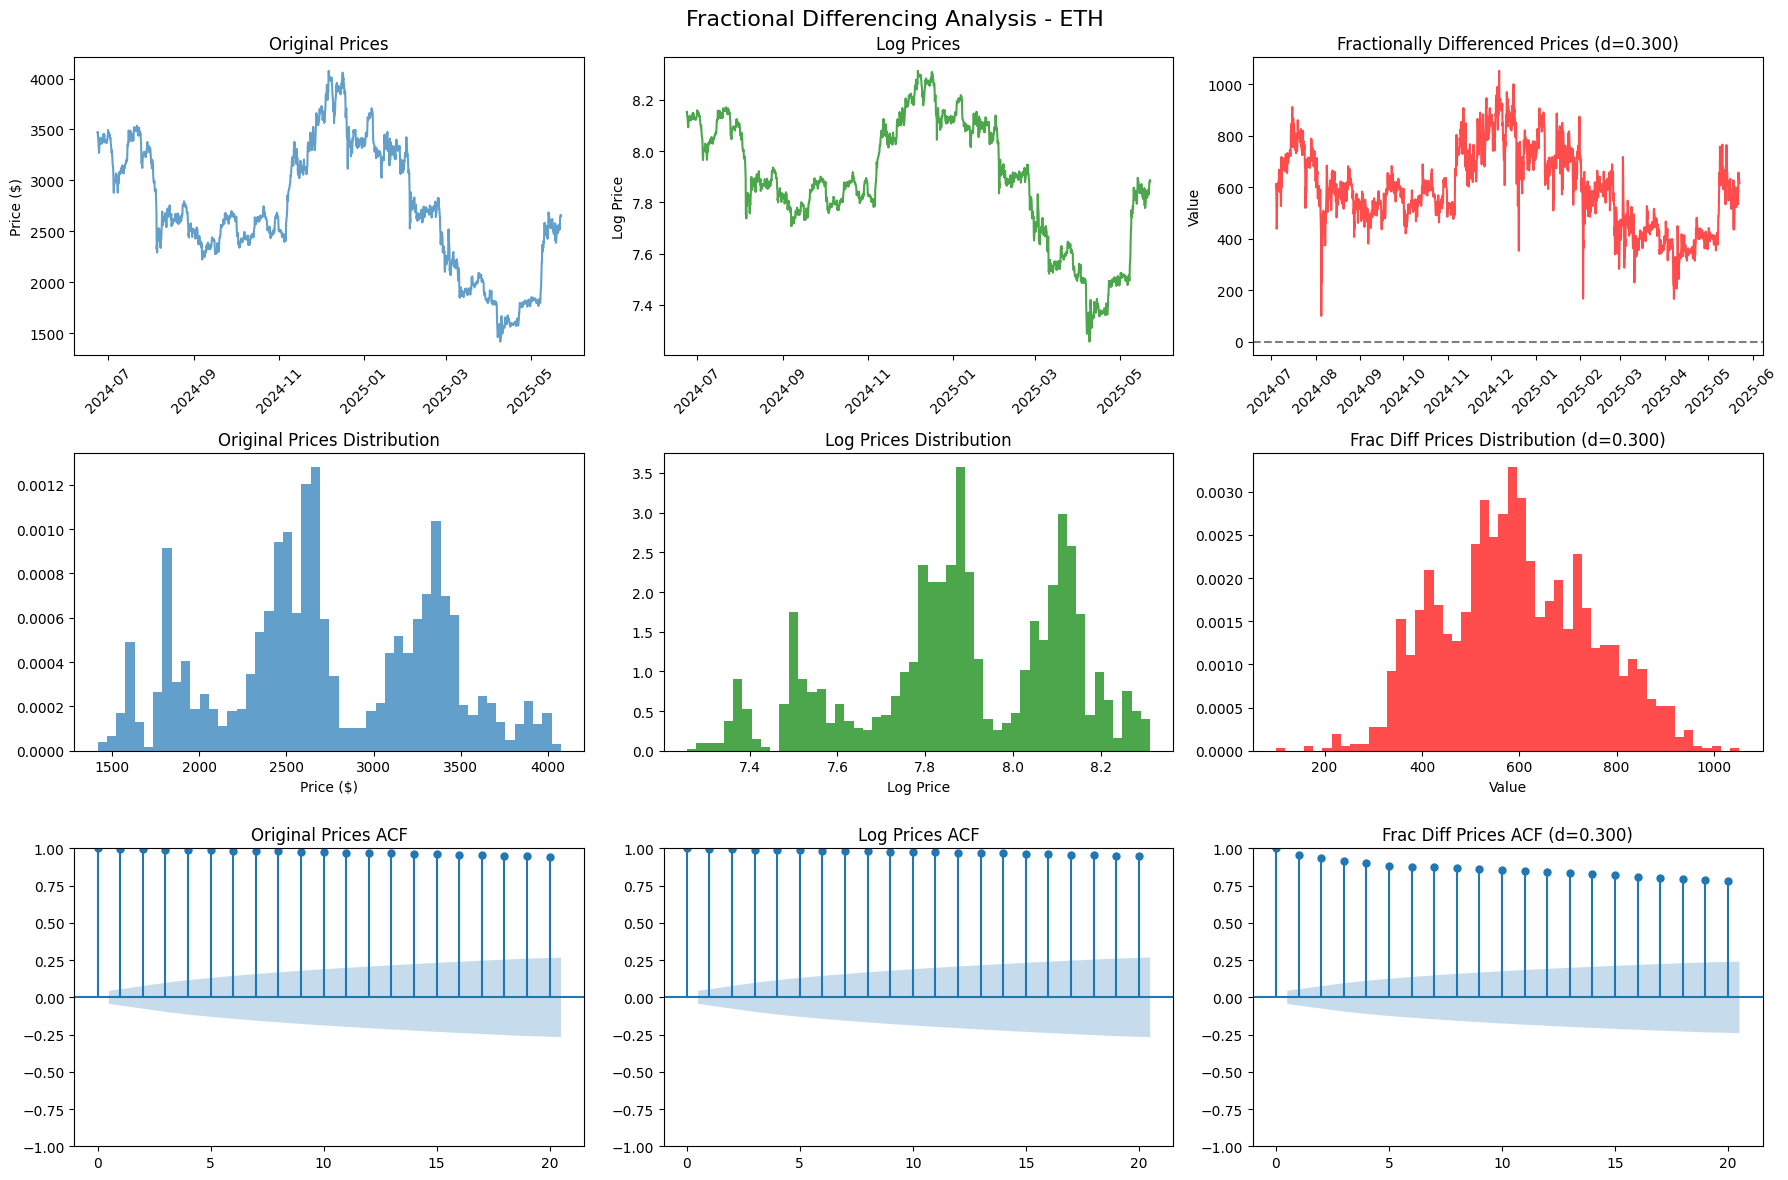

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Fractional Differencing Analysis - ETH', fontsize=16)

# Original vs Fractionally Differenced
axes[0,0].plot(fdf1.index, fdf1['prices'], alpha=0.7, label='Original')
axes[0,0].set_title('Original Prices')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(fdf1.index, fdf1['log_prices'], alpha=0.7, label='Log Prices', color='green')
axes[0,1].set_title('Log Prices')
axes[0,1].set_ylabel('Log Price')
axes[0,1].tick_params(axis='x', rotation=45)

axes[0,2].plot(fdf1.index, fdf1['frac_diff_prices'], alpha=0.7, label=f'Frac Diff (d={optimal_d_prices:.3f})', color='red')
axes[0,2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0,2].set_title(f'Fractionally Differenced Prices (d={optimal_d_prices:.3f})')
axes[0,2].set_ylabel('Value')
axes[0,2].tick_params(axis='x', rotation=45)

# Distributions
axes[1,0].hist(fdf1['prices'].dropna(), bins=50, alpha=0.7, density=True)
axes[1,0].set_title('Original Prices Distribution')
axes[1,0].set_xlabel('Price ($)')

axes[1,1].hist(fdf1['log_prices'].dropna(), bins=50, alpha=0.7, density=True, color='green')
axes[1,1].set_title('Log Prices Distribution')
axes[1,1].set_xlabel('Log Price')

axes[1,2].hist(fdf1['frac_diff_prices'].dropna(), bins=50, alpha=0.7, density=True, color='red')
axes[1,2].set_title(f'Frac Diff Prices Distribution (d={optimal_d_prices:.3f})')
axes[1,2].set_xlabel('Value')

# ACF plots
try:
    sm.graphics.tsa.plot_acf(fdf1['prices'].dropna(), ax=axes[2,0], lags=20)
    axes[2,0].set_title('Original Prices ACF')
except:
    axes[2,0].set_title('Original Prices ACF - Error')

try:
    sm.graphics.tsa.plot_acf(fdf1['log_prices'].dropna(), ax=axes[2,1], lags=20)
    axes[2,1].set_title('Log Prices ACF')
except:
    axes[2,1].set_title('Log Prices ACF - Error')

try:
    sm.graphics.tsa.plot_acf(fdf1['frac_diff_prices'].dropna(), ax=axes[2,2], lags=20)
    axes[2,2].set_title(f'Frac Diff Prices ACF (d={optimal_d_prices:.3f})')
except:
    axes[2,2].set_title('Frac Diff Prices ACF - Error')

plt.tight_layout()
plt.show()

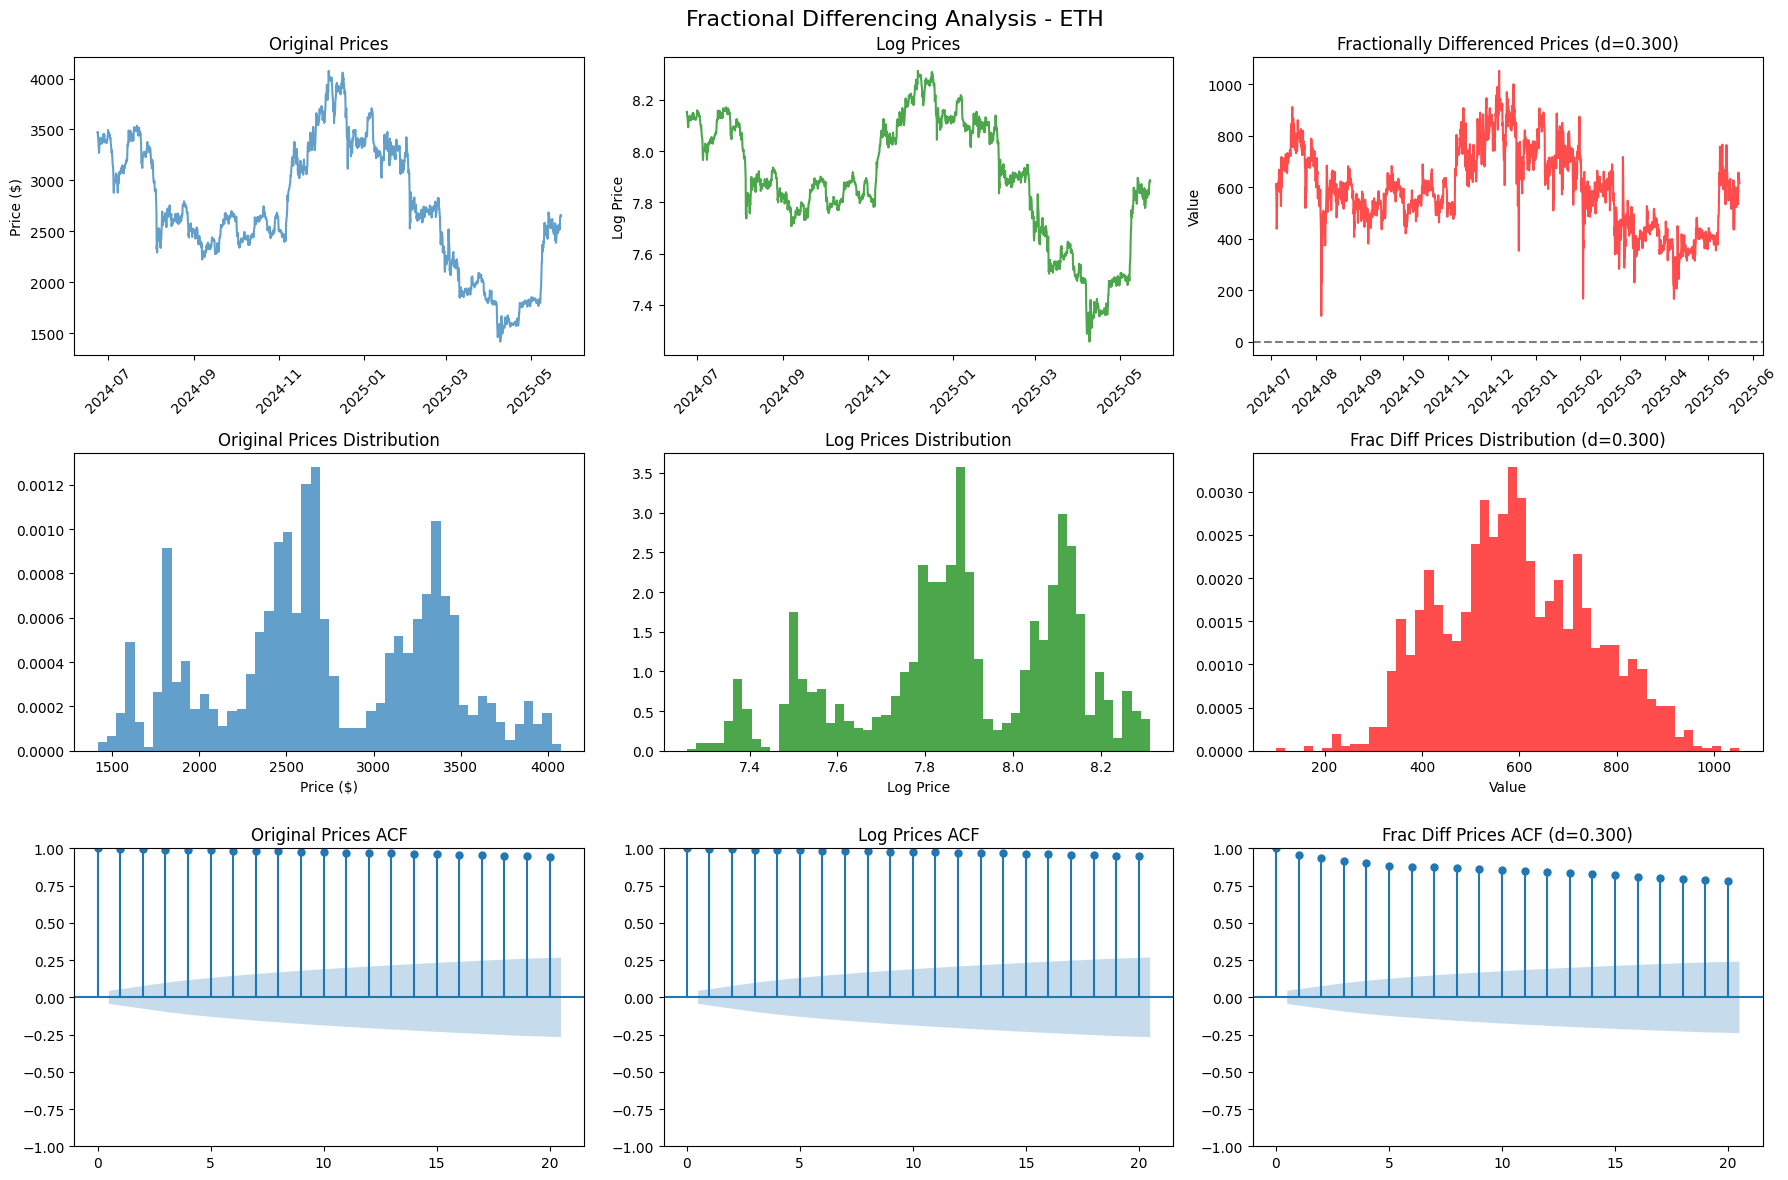

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
fig.suptitle('Fractional Differencing Analysis - ETH', fontsize=16)

# Original vs Fractionally Differenced
axes[0,0].plot(fdf1.index, fdf1['prices'], alpha=0.7, label='Original')
axes[0,0].set_title('Original Prices')
axes[0,0].set_ylabel('Price ($)')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].plot(fdf1.index, fdf1['log_prices'], alpha=0.7, label='Log Prices', color='green')
axes[0,1].set_title('Log Prices')
axes[0,1].set_ylabel('Log Price')
axes[0,1].tick_params(axis='x', rotation=45)

axes[0,2].plot(fdf1.index, fdf1['frac_diff_prices'], alpha=0.7, label=f'Frac Diff (d={optimal_d_prices:.3f})', color='red')
axes[0,2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0,2].set_title(f'Fractionally Differenced Prices (d={optimal_d_prices:.3f})')
axes[0,2].set_ylabel('Value')
axes[0,2].tick_params(axis='x', rotation=45)

# Distributions
axes[1,0].hist(fdf1['prices'].dropna(), bins=50, alpha=0.7, density=True)
axes[1,0].set_title('Original Prices Distribution')
axes[1,0].set_xlabel('Price ($)')

axes[1,1].hist(fdf1['log_prices'].dropna(), bins=50, alpha=0.7, density=True, color='green')
axes[1,1].set_title('Log Prices Distribution')
axes[1,1].set_xlabel('Log Price')

axes[1,2].hist(fdf1['frac_diff_prices'].dropna(), bins=50, alpha=0.7, density=True, color='red')
axes[1,2].set_title(f'Frac Diff Prices Distribution (d={optimal_d_prices:.3f})')
axes[1,2].set_xlabel('Value')

# ACF plots
try:
    sm.graphics.tsa.plot_acf(fdf1['prices'].dropna(), ax=axes[2,0], lags=20)
    axes[2,0].set_title('Original Prices ACF')
except:
    axes[2,0].set_title('Original Prices ACF - Error')

try:
    sm.graphics.tsa.plot_acf(fdf1['log_prices'].dropna(), ax=axes[2,1], lags=20)
    axes[2,1].set_title('Log Prices ACF')
except:
    axes[2,1].set_title('Log Prices ACF - Error')

try:
    sm.graphics.tsa.plot_acf(fdf1['frac_diff_prices'].dropna(), ax=axes[2,2], lags=20)
    axes[2,2].set_title(f'Frac Diff Prices ACF (d={optimal_d_prices:.3f})')
except:
    axes[2,2].set_title('Frac Diff Prices ACF - Error')

plt.tight_layout()
plt.show()

## Graphs

#Step 2A

##Prepare Dataset for Training by adding lags

In [ ]:
step2edf = edf.copy()
step2edf = step2edf.rename(columns={'returns': 'ret'})

name = 'ret'

In [ ]:
step2edf.head()

Price,Close,High,Low,Open,Volume,ret,log_price,log_returns
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD,,,
Datetime,,,,,,,,
2024-06-23 16:00:00+00:00,3476.434814,3478.508057,3461.407227,3472.614014,453107200,0.001385,8.153763,0.001384
2024-06-23 20:00:00+00:00,3418.294922,3477.653320,3408.583008,3477.653320,1652614656,-0.016724,8.136897,-0.016865
2024-06-24 00:00:00+00:00,3401.776367,3429.953857,3391.192383,3418.783203,1696828416,-0.004832,8.132053,-0.004844
2024-06-24 04:00:00+00:00,3368.948242,3410.029297,3355.392334,3400.775391,1960707072,-0.009650,8.122356,-0.009697
2024-06-24 08:00:00+00:00,3318.611328,3390.923584,3276.458740,3367.245850,3985838080,-0.014941,8.107302,-0.015054


In [ ]:
# Set 'Date' as index and keep only 'Ret' column
step2edf = step2edf[['ret']]

step2edf["Ret25_i"] = step2edf[name].rolling(25).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
step2edf["Ret60_i"] = step2edf[name].rolling(60).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
step2edf["Ret90_i"] = step2edf[name].rolling(90).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
step2edf["Ret120_i"] = step2edf[name].rolling(120).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
step2edf["Ret240_i"] = step2edf[name].rolling(240).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))

step2edf = step2edf.dropna()
step2edf.tail(10)

Price,ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i
Ticker,,,,,,
Datetime,,,,,,
2025-05-21 04:00:00+00:00,0.002875,0.027605,0.041035,0.365888,0.363522,0.527100
2025-05-21 08:00:00+00:00,-0.005801,0.023982,0.011592,0.381391,0.339099,0.517894
2025-05-21 12:00:00+00:00,0.011782,0.039670,0.050587,0.391869,0.346473,0.524848
2025-05-21 16:00:00+00:00,-0.019771,0.021443,0.012281,0.363428,0.332676,0.504338
2025-05-21 20:00:00+00:00,0.013342,0.037291,0.025430,0.359903,0.347574,0.516619
2025-05-22 00:00:00+00:00,0.033115,0.068788,0.055049,0.387364,0.376109,0.558776
2025-05-22 04:00:00+00:00,-0.000566,0.067266,0.040603,0.380007,0.392346,0.541068
2025-05-22 08:00:00+00:00,0.009932,0.064259,0.059456,0.391423,0.393669,0.542442


In [ ]:
step2edf["Ret120"] = step2edf["Ret120_i"].shift(-120)
step2edf["Output"] = step2edf["Ret120"] > 0
step2edf["Output"] = step2edf["Output"].astype(int)
del step2edf["Ret120"]
step2edf = step2edf.dropna()
step2edf.tail(10)

Price,ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i,Output
Ticker,,,,,,,
Datetime,,,,,,,
2025-05-21 04:00:00+00:00,0.002875,0.027605,0.041035,0.365888,0.363522,0.527100,0
2025-05-21 08:00:00+00:00,-0.005801,0.023982,0.011592,0.381391,0.339099,0.517894,0
2025-05-21 12:00:00+00:00,0.011782,0.039670,0.050587,0.391869,0.346473,0.524848,0
2025-05-21 16:00:00+00:00,-0.019771,0.021443,0.012281,0.363428,0.332676,0.504338,0
2025-05-21 20:00:00+00:00,0.013342,0.037291,0.025430,0.359903,0.347574,0.516619,0
2025-05-22 00:00:00+00:00,0.033115,0.068788,0.055049,0.387364,0.376109,0.558776,0
2025-05-22 04:00:00+00:00,-0.000566,0.067266,0.040603,0.380007,0.392346,0.541068,0
2025-05-22 08:00:00+00:00,0.009932,0.064259,0.059456,0.391423,0.393669,0.542442,0


## Train test samples and Scaling

In [ ]:
# Train-test split
ts = int(0.2 * len(step2edf))  # Number of observations in test sample (20%)
split_time = len(step2edf) - ts  # Start of test sample
test_time = step2edf.index[split_time:]  # Extract Date index for test period
Ret_vector = step2edf['ret'][split_time:].values  # Extract Ret values for test period
step2edf.tail()

Price,ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i,Output
Ticker,,,,,,,
Datetime,,,,,,,
2025-05-22 00:00:00+00:00,0.033115,0.068788,0.055049,0.387364,0.376109,0.558776,0
2025-05-22 04:00:00+00:00,-0.000566,0.067266,0.040603,0.380007,0.392346,0.541068,0
2025-05-22 08:00:00+00:00,0.009932,0.064259,0.059456,0.391423,0.393669,0.542442,0
2025-05-22 12:00:00+00:00,0.000728,0.068303,0.078289,0.401525,0.390105,0.504326,0
2025-05-22 16:00:00+00:00,-0.003480,0.034062,0.084974,0.409853,0.387726,0.509013,0


In [ ]:
from sklearn.model_selection import train_test_split

Xdf, ydf = step2edf.iloc[:, 1:-1], step2edf.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, shuffle=False
)  # It is important to keep "shuffle=False"
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1408, 5) (352, 5) (1408,) (352,)


##Model and Training

In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()  # We clear the backend to reset the random seed process
tf.random.set_seed(
    1234
)  # We will set a random seed so that results obtained are somewhat replicable

act_fun = "relu"
hp_units = 25
hp_units_2 = 15
hp_units_3 = 10
n_dropout = 0.2

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

hp_lr = 1e-5  # Learning rate

adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)  # Adam optimizer

model.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

### Validation and Early Callbacks & Class Weights

In [ ]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",        # Monitor validation loss
    mode="min",               # Minimize loss
    verbose=1,
    patience=20,
    restore_best_weights=True,
)

class_weight = {0: (np.mean(y_train) / 0.5) * 1.2, 1: 1.0}
print(class_weight)

{0: np.float32(0.93750006), 1: 1.0}


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=2,
    callbacks=[es],
    class_weight=class_weight,
)

Epoch 1/500
36/36 - 3s - 70ms/step - accuracy: 0.5107 - loss: 0.6714 - val_accuracy: 0.1241 - val_loss: 0.7044
Epoch 2/500
36/36 - 0s - 5ms/step - accuracy: 0.5240 - loss: 0.6703 - val_accuracy: 0.1206 - val_loss: 0.7045
Epoch 3/500
36/36 - 0s - 8ms/step - accuracy: 0.5018 - loss: 0.6709 - val_accuracy: 0.1206 - val_loss: 0.7045
Epoch 4/500
36/36 - 0s - 8ms/step - accuracy: 0.4849 - loss: 0.6710 - val_accuracy: 0.1241 - val_loss: 0.7044
Epoch 5/500
36/36 - 0s - 8ms/step - accuracy: 0.4991 - loss: 0.6704 - val_accuracy: 0.1241 - val_loss: 0.7043
Epoch 6/500
36/36 - 0s - 8ms/step - accuracy: 0.4929 - loss: 0.6713 - val_accuracy: 0.1241 - val_loss: 0.7043
Epoch 7/500
36/36 - 0s - 5ms/step - accuracy: 0.4831 - loss: 0.6708 - val_accuracy: 0.1277 - val_loss: 0.7043
Epoch 8/500
36/36 - 0s - 9ms/step - accuracy: 0.4911 - loss: 0.6717 - val_accuracy: 0.1277 - val_loss: 0.7043
Epoch 9/500
36/36 - 0s - 7ms/step - accuracy: 0.4831 - loss: 0.6698 - val_accuracy: 0.1277 - val_loss: 0.7042
Epoch 10/

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135 (8.34 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,424 (5.57 KB)

## Financial Performance (prediction accuracy)

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.where(y_prob > 0.50, 1, 0)

acc = model.evaluate(X_test, y_test)
print("Model accuracy in test: ", acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6057 - loss: 0.6903 
Model accuracy in test:  [0.6891176104545593, 0.6278409361839294]


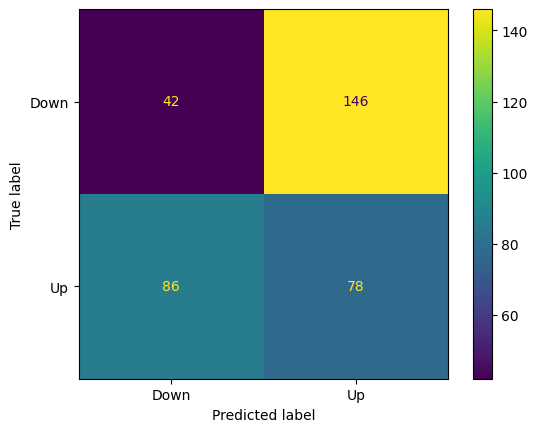

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = metrics.confusion_matrix(y_test.values, y_pred[:,0])
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot()

## Trading Strategy resutsl

In [ ]:
df_predictions = pd.DataFrame(
    {
        'Date': test_time,  # No flatten needed for DatetimeIndex
        'Pred': y_pred.flatten() if y_pred.ndim > 1 else y_pred,  # Flatten if 2D
        'Ret': Ret_vector.flatten() if Ret_vector.ndim > 1 else Ret_vector,  # Flatten if 2D
    }
)
df_predictions.tail()

,Date,Pred,Ret
347,2025-05-22 00:00:00+00:00,0,0.033115
348,2025-05-22 04:00:00+00:00,0,-0.000566
349,2025-05-22 08:00:00+00:00,0,0.009932
350,2025-05-22 12:00:00+00:00,0,0.000728
351,2025-05-22 16:00:00+00:00,0,-0.003480


In [ ]:
df = df_predictions

df['Ret'] = df['Ret'] / 100

df["Positions"] = np.where(df["Pred"] > 0.5, 1, -1)
df["Strat_ret"] = df["Positions"].shift(1) * df["Ret"]
df["Positions_L"] = df["Positions"].shift(1)
df["Positions_L"][df["Positions_L"] == -1] = 0
df["Strat_ret_L"] = df["Positions_L"] * df["Ret"]
df["CumRet"] = df["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["CumRet_L"] = df["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["bhRet"] = df["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

Strat Return Long Only = -0.040076009810019464 %
Strat Return = -0.3893284677783937 %
Buy and Hold Return = 0.3152775584862155 %


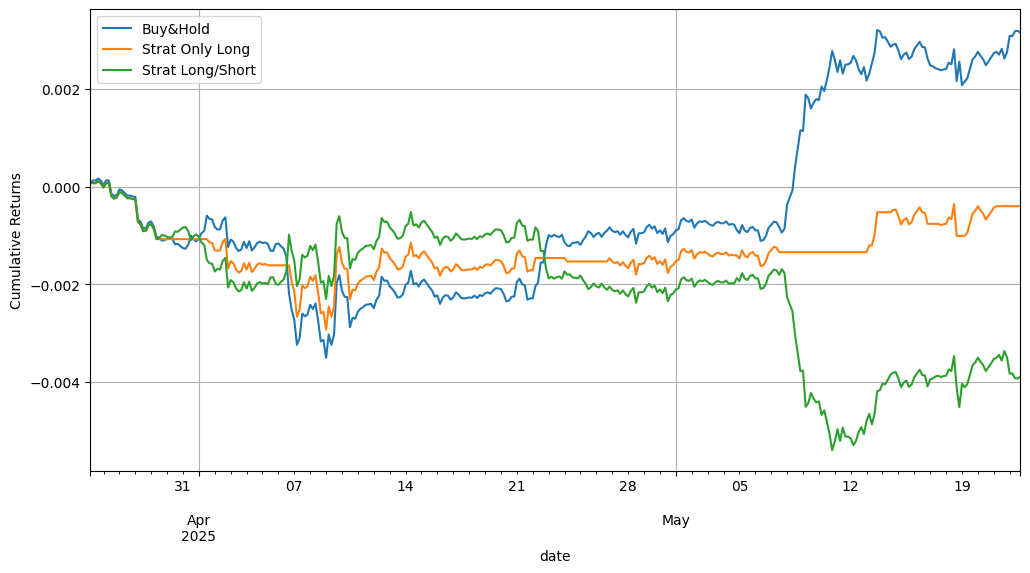

,Pred,Ret,Positions,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet
count,352.000000,352.000000,352.000000,351.000000,351.000000,351.000000,351.000000,351.000000,352.000000
mean,0.681818,0.000009,0.363636,-0.000011,0.683761,-0.000001,-0.002098,-0.001294,-0.000435
std,0.466434,0.000177,0.932867,0.000177,0.465671,0.000140,0.001310,0.000513,0.001813
min,0.000000,-0.000753,-1.000000,-0.000744,0.000000,-0.000651,-0.005392,-0.002927,-0.003502
25%,0.000000,-0.000068,-1.000000,-0.000075,0.000000,-0.000027,-0.002392,-0.001597,-0.001931
50%,1.000000,0.000008,1.000000,0.000005,1.000000,0.000000,-0.001895,-0.001391,-0.000938
75%,1.000000,0.000077,1.000000,0.000065,1.000000,0.000043,-0.001053,-0.001075,0.000127
max,1.000000,0.001067,1.000000,0.001067,1.000000,0.001067,0.000114,0.000114,0.003203


In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df.describe()

# Step 2B

## Data Preparation for training by adding lags


In [ ]:
df2b = df1b.copy()
df2b.head()
df2b = df2b.rename(columns={'log_returns': 'ret'})

name = 'ret'

In [ ]:
# Set 'Date' as index and keep only 'Ret' column
df2b = df2b[['ret']]

df2b["Ret25_i"] = df2b[name].rolling(25).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df2b["Ret60_i"] = df2b[name].rolling(60).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df2b["Ret90_i"] = df2b[name].rolling(90).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df2b["Ret120_i"] = df2b[name].rolling(120).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df2b["Ret240_i"] = df2b[name].rolling(240).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))

df2b = df2b.dropna()
df2b.tail(10)

Price,ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i
Ticker,,,,,,
Datetime,,,,,,
2025-05-21 04:00:00+00:00,0.002871,0.022148,0.031135,0.346417,0.343219,0.498529
2025-05-21 08:00:00+00:00,-0.005818,0.018511,0.001953,0.362130,0.318954,0.489314
2025-05-21 12:00:00+00:00,0.011713,0.034136,0.041252,0.372538,0.326268,0.496209
2025-05-21 16:00:00+00:00,-0.019969,0.015714,0.002921,0.343940,0.312293,0.475506
2025-05-21 20:00:00+00:00,0.013254,0.031476,0.015980,0.340468,0.327101,0.487695
2025-05-22 00:00:00+00:00,0.032578,0.062436,0.045066,0.367402,0.355103,0.529340
2025-05-22 04:00:00+00:00,-0.000566,0.060914,0.030716,0.360070,0.371478,0.511782
2025-05-22 08:00:00+00:00,0.009883,0.057941,0.049559,0.371435,0.372790,0.513143


## Train test samples and Scaling

In [ ]:
# Train-test split
ts = int(0.2 * len(df2b))  # Number of observations in test sample (20%)
split_time = len(df2b) - ts  # Start of test sample
test_time = df2b.index[split_time:]  # Extract Date index for test period
Ret_vector = df2b['ret'][split_time:].values  # Extract Ret values for test period
df2b.tail()

Price,ret,Ret25_i,Ret60_i,Ret90_i,Ret120_i,Ret240_i
Ticker,,,,,,
Datetime,,,,,,
2025-05-22 00:00:00+00:00,0.032578,0.062436,0.045066,0.367402,0.355103,0.529340
2025-05-22 04:00:00+00:00,-0.000566,0.060914,0.030716,0.360070,0.371478,0.511782
2025-05-22 08:00:00+00:00,0.009883,0.057941,0.049559,0.371435,0.372790,0.513143
2025-05-22 12:00:00+00:00,0.000728,0.061990,0.068555,0.381579,0.369235,0.475769
2025-05-22 16:00:00+00:00,-0.003486,0.028209,0.075286,0.389969,0.366851,0.480481


In [ ]:
from sklearn.model_selection import train_test_split

Xdf, ydf = step2edf.iloc[:, 1:-1], step2edf.iloc[:, -1]
X = Xdf.astype("float32")
y = ydf.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, shuffle=False
)  # It is important to keep "shuffle=False"
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1409, 5) (351, 5) (1409,) (351,)


##Model and Training


In [ ]:
import tensorflow as tf

tf.keras.backend.clear_session()  # We clear the backend to reset the random seed process
tf.random.set_seed(
    1234
)  # We will set a random seed so that results obtained are somewhat replicable

act_fun = "relu"
hp_units = 25
hp_units_2 = 15
hp_units_3 = 10
n_dropout = 0.2

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))
model.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

hp_lr = 1e-5  # Learning rate

adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)  # Adam optimizer

model.compile(optimizer=adam, loss="binary_crossentropy", metrics=["accuracy"])

### Validation and Early Callbacks & Class Weights

In [ ]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    verbose=1,
    patience=20,
    restore_best_weights=True,
)

class_weight = {0: (np.mean(y_train) / 0.5) * 1.2, 1: 1.0}
print(class_weight)

{0: np.float32(0.9368347), 1: 1.0}


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    batch_size=32,
    verbose=2,
    callbacks=[es],
    class_weight=class_weight,
)

Epoch 1/500
36/36 - 2s - 67ms/step - accuracy: 0.4845 - loss: 0.6714 - val_accuracy: 0.8901 - val_loss: 0.6778
Epoch 2/500
36/36 - 0s - 11ms/step - accuracy: 0.4818 - loss: 0.6710 - val_accuracy: 0.8901 - val_loss: 0.6776
Epoch 3/500
36/36 - 0s - 5ms/step - accuracy: 0.4898 - loss: 0.6707 - val_accuracy: 0.8936 - val_loss: 0.6774
Epoch 4/500
36/36 - 0s - 9ms/step - accuracy: 0.4747 - loss: 0.6711 - val_accuracy: 0.8936 - val_loss: 0.6772
Epoch 5/500
36/36 - 0s - 6ms/step - accuracy: 0.4951 - loss: 0.6714 - val_accuracy: 0.8972 - val_loss: 0.6770
Epoch 6/500
36/36 - 0s - 5ms/step - accuracy: 0.4676 - loss: 0.6712 - val_accuracy: 0.8972 - val_loss: 0.6769
Epoch 7/500
36/36 - 0s - 5ms/step - accuracy: 0.4765 - loss: 0.6710 - val_accuracy: 0.8972 - val_loss: 0.6767
Epoch 8/500
36/36 - 0s - 9ms/step - accuracy: 0.4925 - loss: 0.6709 - val_accuracy: 0.8972 - val_loss: 0.6765
Epoch 9/500
36/36 - 0s - 6ms/step - accuracy: 0.5093 - loss: 0.6703 - val_accuracy: 0.8972 - val_loss: 0.6763
Epoch 10

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135 (8.34 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,424 (5.57 KB)

## Financial Performance / Prediction

In [ ]:
y_prob = model.predict(X_test)
y_pred = np.where(y_prob > 0.50, 1, 0)

acc = model.evaluate(X_test, y_test)
print("Model accuracy in test: ", acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4765 - loss: 0.6976 
Model accuracy in test:  [0.6946681141853333, 0.5014244914054871]


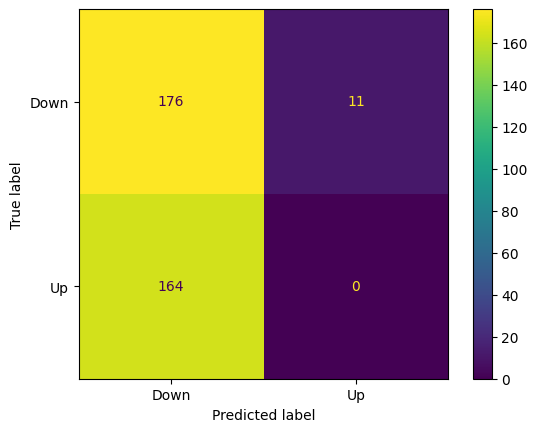

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = metrics.confusion_matrix(y_test.values, y_pred[:,0])
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot()

## Trading Strategy Results

In [ ]:
df_predictions = pd.DataFrame(
    {
        'Date': test_time,  # No flatten needed for DatetimeIndex
        'Pred': y_pred.flatten() if y_pred.ndim > 1 else y_pred,  # Flatten if 2D
        'Ret': Ret_vector.flatten() if Ret_vector.ndim > 1 else Ret_vector,  # Flatten if 2D
    }
)
df_predictions.tail()

,Date,Pred,Ret
346,2025-05-19 20:00:00+00:00,0,0.005933
347,2025-05-20 00:00:00+00:00,0,0.009492
348,2025-05-20 04:00:00+00:00,0,-0.008294
349,2025-05-20 08:00:00+00:00,0,-0.006949
350,2025-05-20 12:00:00+00:00,0,-0.012225


In [ ]:
df = df_predictions

df['Ret'] = df['Ret'] / 100

df["Positions"] = np.where(df["Pred"] > 0.5, 1, -1)
df["Strat_ret"] = df["Positions"].shift(1) * df["Ret"]
df["Positions_L"] = df["Positions"].shift(1)
df["Positions_L"][df["Positions_L"] == -1] = 0
df["Strat_ret_L"] = df["Positions_L"] * df["Ret"]
df["CumRet"] = df["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["CumRet_L"] = df["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["bhRet"] = df["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

Final_Return_L = np.prod(1 + df["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df["Ret"]) - 1

print("Strat Return Long Only =", Final_Return_L * 100, "%")
print("Strat Return =", Final_Return * 100, "%")
print("Buy and Hold Return =", Buy_Return * 100, "%")

Strat Return Long Only = -0.11749340808624442 %
Strat Return = -0.44616880271571846 %
Buy and Hold Return = 0.21364352514996465 %


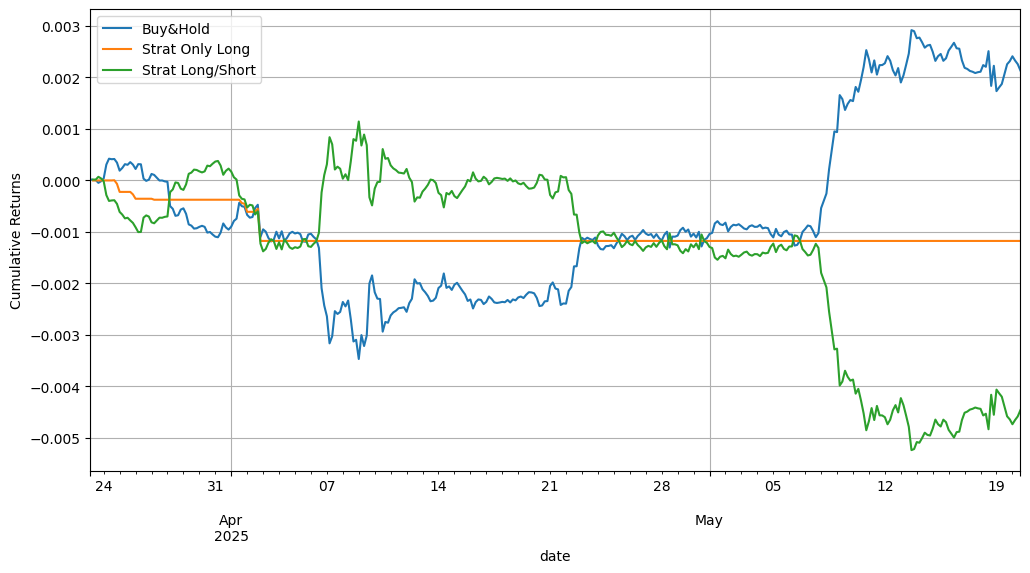

,Pred,Ret,Positions,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet
count,351.000000,351.000000,351.000000,350.000000,350.000000,350.000000,350.000000,350.000000,351.000000
mean,0.031339,0.000006,-0.937322,-0.000013,0.031429,-0.000003,-0.001404,-0.001021,-0.000614
std,0.174481,0.000176,0.348962,0.000176,0.174723,0.000036,0.001696,0.000336,0.001621
min,0.000000,-0.000783,-1.000000,-0.001014,0.000000,-0.000628,-0.005238,-0.001175,-0.003468
25%,0.000000,-0.000068,-1.000000,-0.000076,0.000000,0.000000,-0.001443,-0.001175,-0.002001
50%,0.000000,0.000007,-1.000000,-0.000012,0.000000,-0.000000,-0.001139,-0.001175,-0.001002
75%,0.000000,0.000073,-1.000000,0.000065,0.000000,0.000000,-0.000062,-0.001175,0.000117
max,1.000000,0.001014,1.000000,0.000783,1.000000,0.000062,0.001145,0.000004,0.002920


In [ ]:
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df.describe()

# Step 2C

## Prepare dataset for training and adding lags


In [ ]:
step2fdf = fdf1.copy()

# Choose which fractionally differenced series to use
# Option 1: If using fractionally differenced prices
if 'frac_diff_prices' in fdf1.columns:
    step2fdf = step2fdf.rename(columns={'frac_diff_prices': 'frac_diff'})
    name = 'frac_diff'
# Option 2: If using fractionally differenced log prices
elif 'frac_diff_log_prices' in fdf1.columns:
    step2fdf = step2fdf.rename(columns={'frac_diff_log_prices': 'frac_diff'})
    name = 'frac_diff'
else:
    # If column names are different, adjust accordingly
    print("Available columns:", fdf1.columns.tolist())


step2fdf = step2fdf[[name]].dropna()

print(f"Working with {name} column")
print(f"Data shape after dropping NaNs: {step2fdf.shape}")
print(f"Data range: [{step2fdf[name].min():.6f}, {step2fdf[name].max():.6f}]")


Working with frac_diff column
Data shape after dropping NaNs: (1934, 1)
Data range: [100.035759, 1052.099605]


In [ ]:
step2fdf[f"{name}_25_mean"] = step2fdf[name].rolling(25).mean()
step2fdf[f"{name}_60_mean"] = step2fdf[name].rolling(60).mean()
step2fdf[f"{name}_90_mean"] = step2fdf[name].rolling(90).mean()
step2fdf[f"{name}_120_mean"] = step2fdf[name].rolling(120).mean()
step2fdf[f"{name}_240_mean"] = step2fdf[name].rolling(240).mean()

print(f"\nFinal dataframe shape: {step2fdf.shape}")
print(f"Columns created: {step2fdf.columns.tolist()}")

step2fdf.tail(10)


Final dataframe shape: (1934, 6)
Columns created: ['frac_diff', 'frac_diff_25_mean', 'frac_diff_60_mean', 'frac_diff_90_mean', 'frac_diff_120_mean', 'frac_diff_240_mean']


,frac_diff,frac_diff_25_mean,frac_diff_60_mean,frac_diff_90_mean,frac_diff_120_mean,frac_diff_240_mean
Datetime,,,,,,
2025-05-19 00:00:00+00:00,436.708540,557.188407,609.116852,550.916948,515.634274,444.262218
2025-05-19 04:00:00+00:00,486.542124,553.215043,604.598185,551.732088,516.138643,445.054516
2025-05-19 08:00:00+00:00,508.185068,551.584142,601.777975,552.949451,516.807891,446.107914
2025-05-19 12:00:00+00:00,555.550017,550.333788,600.921709,554.632100,518.036284,447.194207
2025-05-19 16:00:00+00:00,589.319355,550.078364,600.185999,556.710187,519.465424,447.779366
2025-05-19 20:00:00+00:00,586.791140,551.225617,599.365557,558.985196,521.104930,448.441673
2025-05-20 00:00:00+00:00,599.982846,552.068330,599.092982,561.465954,522.718064,449.479397
2025-05-20 04:00:00+00:00,566.652258,550.095305,597.310125,563.179528,524.177122,450.438712
2025-05-20 08:00:00+00:00,549.805344,547.176959,596.058518,565.001642,525.300338,451.311113


## Train test samples and scaling

In [ ]:
target_col = 'frac_diff'
ts = int(0.2 * len(step2fdf))  # Number of observations in test sample (20%)
split_time = len(step2fdf) - ts  # Start of test sample
test_time = step2fdf.index[split_time:]  # Extract Date index for test period
FracDiff_vector = step2fdf[target_col][split_time:].values  # Extract fractional diff values for test period
step2fdf.tail()

,frac_diff,frac_diff_25_mean,frac_diff_60_mean,frac_diff_90_mean,frac_diff_120_mean,frac_diff_240_mean
Datetime,,,,,,
2025-05-19 20:00:00+00:00,586.791140,551.225617,599.365557,558.985196,521.104930,448.441673
2025-05-20 00:00:00+00:00,599.982846,552.068330,599.092982,561.465954,522.718064,449.479397
2025-05-20 04:00:00+00:00,566.652258,550.095305,597.310125,563.179528,524.177122,450.438712
2025-05-20 08:00:00+00:00,549.805344,547.176959,596.058518,565.001642,525.300338,451.311113
2025-05-20 12:00:00+00:00,523.080591,542.800601,593.559999,566.543346,526.666466,452.475680


In [ ]:
from sklearn.model_selection import train_test_split

# Extract features (all columns except the target) and target
# Assuming the target column is the first column and features are the rest
if target_col == step2fdf.columns[0]:
    # If target is first column, features are columns 1 onwards
    Xdf = step2fdf.iloc[:, 1:]
    ydf = step2fdf.iloc[:, 0]
else:
    # If target is not first column, exclude it from features
    feature_cols = [col for col in step2fdf.columns if col != target_col]
    Xdf = step2fdf[feature_cols]
    ydf = step2fdf[target_col]

print(f"\nFeatures shape: {Xdf.shape}")
print(f"Target shape: {ydf.shape}")
print(f"Feature columns: {Xdf.columns.tolist()}")

# Convert to float32 for memory efficiency
X = Xdf.astype("float32")
y = ydf.astype("float32")

# Split the data (maintaining time order with shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=ts, shuffle=False)


Features shape: (1934, 5)
Target shape: (1934,)
Feature columns: ['frac_diff_25_mean', 'frac_diff_60_mean', 'frac_diff_90_mean', 'frac_diff_120_mean', 'frac_diff_240_mean']


## Model and training

In [ ]:
import tensorflow as tf
import numpy as np

# Clear session and set random seed for reproducibility
tf.keras.backend.clear_session()
tf.random.set_seed(1234)
np.random.seed(1234)

# Model Architecture Parameters (adapted for regression)
act_fun = "relu"  # Activation function for hidden layers
hp_units = 25     # First hidden layer units
hp_units_2 = 15   # Second hidden layer units
hp_units_3 = 10   # Third hidden layer units
n_dropout = 0.2   # Dropout rate for regularization

# Build the Sequential Model (adapted for regression)
model = tf.keras.models.Sequential()

# First hidden layer
model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun, input_shape=(X_train.shape[1],)))
model.add(tf.keras.layers.Dropout(n_dropout))

# Second hidden layer
model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))

# Third hidden layer
model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
model.add(tf.keras.layers.Dropout(n_dropout))

# Output layer (changed for regression)
model.add(tf.keras.layers.Dense(units=1, activation="linear"))  # Linear activation for regression

# Display model architecture
print("Model Architecture:")
model.summary()


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 711 (2.78 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Optimizer and Learning Rate
hp_lr = 1e-3  # Learning rate (increased from 1e-5 for regression)
adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)

# Compile model (adapted for regression)
model.compile(
    optimizer=adam,
    loss="mse",  # Mean Squared Error for regression
    metrics=["mae"]  # Mean Absolute Error as additional metric
)

print(f"Model compiled with learning rate: {hp_lr}")

# Early Stopping Callback (adapted for regression)
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",  # Monitor validation loss for regression
    mode="min",          # Minimize the loss
    verbose=1,
    patience=20,         # Patience for early stopping
    restore_best_weights=True,
)

# Additional Callbacks for monitoring
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Data preprocessing - Standardization (important for regression)
from sklearn.preprocessing import StandardScaler

# Fit scaler on training data only
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# For target, we'll scale but keep track for inverse transform
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Data scaling complete:")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_scaled range: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")

# Train the model
print("\nStarting model training...")

history = model.fit(
    X_train_scaled,          # Scaled training features
    y_train_scaled,          # Scaled training targets
    validation_split=0.2,    # 20% of training data for validation
    epochs=500,              # Maximum epochs
    batch_size=32,           # Batch size
    verbose=1,               # Verbose output
    callbacks=[es, reduce_lr],  # Early stopping and learning rate reduction
)



Model compiled with learning rate: 0.001
Data scaling complete:
X_train_scaled shape: (1408, 5)
y_train_scaled range: [-0.8006, 1.2490]

Starting model training...
Epoch 1/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1.1584 - mae: 1.0470 - val_loss: 1.5049 - val_mae: 1.2235 - learning_rate: 0.0010
Epoch 2/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0936 - mae: 1.0288 - val_loss: 1.3112 - val_mae: 1.1423 - learning_rate: 0.0010
Epoch 3/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0527 - mae: 1.0161 - val_loss: 1.1981 - val_mae: 1.0901 - learning_rate: 0.0010
Epoch 4/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0127 - mae: 0.9983 - val_loss: 1.1242 - val_mae: 1.0535 - learning_rate: 0.0010
Epoch 5/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0013 - mae: 0.9931 - val_loss: 1.0904 - val_mae: 1.0351 - learning_rate: 0.0010
Epoch 6/500
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9815 - mae: 0.9804 - val_loss: 1.0648 - val_mae: 1.0202 - learning_ra

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135 (8.34 KB)

 Trainable params: 711 (2.78 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,424 (5.57 KB)

## Trading Strategy and Results

In [ ]:
y_prob = model.predict(X_test_scaled)  # Raw predictions from model
y_pred_continuous = scaler_y.inverse_transform(y_prob).ravel()  # Scale back to original units

y_pred_binary = np.where(y_pred_continuous > 0, 1, 0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
print(f"Trading signals generated:")
print(f"  Up signals (1): {np.sum(y_pred_binary)}")
print(f"  Down signals (0): {np.sum(1 - y_pred_binary)}")
print(f"  Signal ratio: {np.mean(y_pred_binary):.2%}")

Trading signals generated:
  Up signals (1): 352
  Down signals (0): 0
  Signal ratio: 100.00%


In [ ]:
y_test_binary = np.where(y_test.values > 0, 1, 0)

In [ ]:
print(f"Actual movements:")
print(f"  Up movements (1): {np.sum(y_test_binary)}")
print(f"  Down movements (0): {np.sum(1 - y_test_binary)}")
print(f"  Actual up ratio: {np.mean(y_test_binary):.2%}")

Actual movements:
  Up movements (1): 177
  Down movements (0): 175
  Actual up ratio: 50.28%


In [ ]:
accuracy = np.mean(y_test_binary == y_pred_binary)
print(f"Directional Accuracy: {accuracy:.2%}")


Directional Accuracy: 50.28%


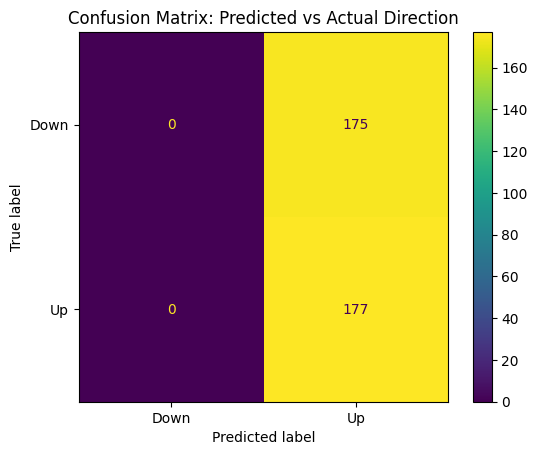

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
disp.plot()
plt.title("Confusion Matrix: Predicted vs Actual Direction")
plt.show()


In [ ]:
print(f"Length of y_test.index: {len(y_test.index)}") # Check the index length
print(f"Length of y_pred_binary: {len(y_pred_binary)}")
print(f"Length of y_pred_continuous: {len(y_pred_continuous)}")
print(f"Length of y_test.values: {len(y_test.values)}")
print(f"Length of y_test_binary: {len(y_test_binary)}")

Length of y_test.index: 352
Length of y_pred_binary: 352
Length of y_pred_continuous: 352
Length of y_test.values: 352
Length of y_test_binary: 352


In [ ]:
print(f"Length of test_time: {len(test_time)}")
print(f"Length of y_pred_binary: {len(y_pred_binary)}")
print(f"Length of y_pred_continuous: {len(y_pred_continuous)}")
print(f"Length of y_test.values: {len(y_test.values)}")
print(f"Length of y_test_binary: {len(y_test_binary)}")

Length of test_time: 351
Length of y_pred_binary: 352
Length of y_pred_continuous: 352
Length of y_test.values: 352
Length of y_test_binary: 352


In [ ]:
# Create the DataFrame using y_test.index
df_predictions = pd.DataFrame({
    'Date': y_test.index,  # Use the index directly from y_test
    'Pred': y_pred_binary,  # Binary predictions (0/1)
    'Pred_Continuous': y_pred_continuous,  # Continuous predictions
    'Actual': y_test.values,  # Actual fractional differences
    'Actual_Binary': y_test_binary,  # Actual binary direction
})

print("\ndf_predictions created successfully:")
print(df_predictions.head())
print(f"Length of df_predictions: {len(df_predictions)}")


df_predictions created successfully:
                       Date  Pred  Pred_Continuous  Actual  Actual_Binary
0 2025-03-25 04:00:00+00:00     1         0.391724     0.0              0
1 2025-03-25 08:00:00+00:00     1         0.391879     0.0              0
2 2025-03-25 12:00:00+00:00     1         0.391888     0.0              0
3 2025-03-25 16:00:00+00:00     1         0.391770     0.0              0
4 2025-03-25 20:00:00+00:00     1         0.391776     0.0              0
Length of df_predictions: 352


In [ ]:
df_predictions = pd.DataFrame({
    'Date': y_test.index,
    'Pred': y_pred_binary,  # Binary predictions (0/1)
    'Pred_Continuous': y_pred_continuous,  # Continuous predictions
    'Actual': y_test.values,  # Actual fractional differences
    'Actual_Binary': y_test_binary,  # Actual binary direction
})

In [ ]:
try:
    # Try to get returns from the original data (adjust as needed)
    # This assumes your original df had returns aligned with the fractional differences
    start_idx = len(step2fdf) - len(y_test)
    if 'returns' in fdf1.columns:
        actual_returns = fdf1['returns'].iloc[start_idx:].values
        df_predictions['Ret'] = actual_returns
    else:
        # If no returns available, we'll simulate based on direction
        print("Warning: No returns found, simulating from directions")
        # Simulate returns based on actual directions (this is an approximation)
        np.random.seed(42)
        base_return = 0.01  # Base return magnitude
        noise = np.random.normal(0, 0.005, len(y_test_binary))
        simulated_returns = base_return * (2 * y_test_binary - 1) + noise
        df_predictions['Ret'] = simulated_returns
except:
    # Fallback: simulate returns
    print("Warning: Using simulated returns for strategy evaluation")
    np.random.seed(42)
    base_return = 0.01
    noise = np.random.normal(0, 0.005, len(y_test_binary))
    simulated_returns = base_return * (2 * y_test_binary - 1) + noise
    df_predictions['Ret'] = simulated_returns

In [ ]:
df = df_predictions.copy()

# Convert returns to decimal if they're in percentage
if np.abs(df['Ret'].mean()) > 1:  # Likely in percentage
    df['Ret'] = df['Ret'] / 100

# Generate positions based on predictions
df["Positions"] = np.where(df["Pred"] > 0.5, 1, -1)  # Long/Short strategy
df["Strat_ret"] = df["Positions"].shift(1) * df["Ret"]  # Strategy returns

# Long-only strategy
df["Positions_L"] = df["Positions"].shift(1).copy()
df["Positions_L"][df["Positions_L"] == -1] = 0  # Convert short to no position
df["Strat_ret_L"] = df["Positions_L"] * df["Ret"]  # Long-only returns

# Remove first row (NaN due to shift)
df = df.dropna()

# Calculate cumulative returns
df["CumRet"] = df["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["CumRet_L"] = df["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df["bhRet"] = df["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

# Calculate final returns
Final_Return_L = np.prod(1 + df["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df["Ret"]) - 1

print(f"TRADING STRATEGY RESULTS:")
print(f"  Long Only Strategy: {Final_Return_L * 100:.2f}%")
print(f"  Long/Short Strategy: {Final_Return * 100:.2f}%")
print(f"  Buy and Hold: {Buy_Return * 100:.2f}%")

TRADING STRATEGY RESULTS:
  Long Only Strategy: 1.39%
  Long/Short Strategy: 1.39%
  Buy and Hold: 1.39%


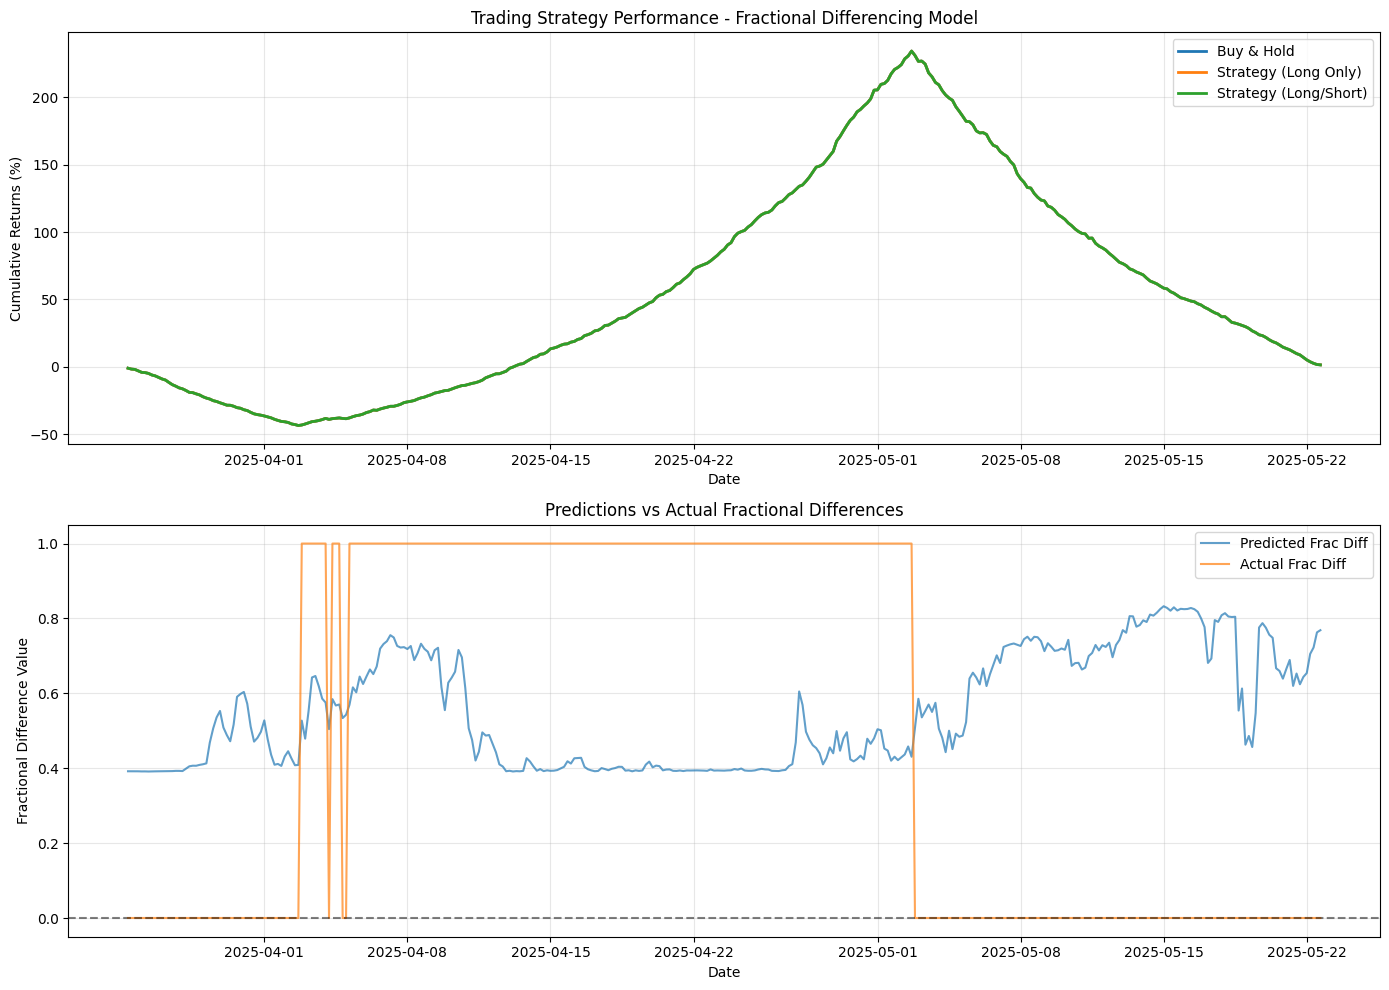

In [ ]:
# Plot cumulative returns
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Cumulative returns plot
ax1.plot(df["Date"], df["bhRet"] * 100, label="Buy & Hold", linewidth=2)
ax1.plot(df["Date"], df["CumRet_L"] * 100, label="Strategy (Long Only)", linewidth=2)
ax1.plot(df["Date"], df["CumRet"] * 100, label="Strategy (Long/Short)", linewidth=2)
ax1.set_xlabel("Date")
ax1.set_ylabel("Cumulative Returns (%)")
ax1.set_title("Trading Strategy Performance - Fractional Differencing Model")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Predictions vs actual (time series)
ax2.plot(df["Date"], df["Pred_Continuous"], label="Predicted Frac Diff", alpha=0.7)
ax2.plot(df["Date"], df["Actual"], label="Actual Frac Diff", alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel("Date")
ax2.set_ylabel("Fractional Difference Value")
ax2.set_title("Predictions vs Actual Fractional Differences")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 3

## Step 3 A


In [ ]:
#Convert time series to GAF

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,985 (1.20 MB)

 Trainable params: 313,985 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0829 - mae: 0.2380 - val_loss: 0.0600 - val_mae: 0.2075
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0484 - mae: 0.1875 - val_loss: 0.0557 - val_mae: 0.1999
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 0.0443 - mae: 0.1784 - val_loss: 0.0535 - val_mae: 0.1947
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0423 - mae: 0.1696 - val_loss: 0.0499 - val_mae: 0.1843
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0394 - mae: 0.1646 - val_loss: 0.0531 - val_mae: 0.1902
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0357 - mae: 0.1540 - val_loss: 0.0436 - val_mae: 0.1698
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0337 - mae: 0.1507 - val_loss: 0.0455 - val_mae: 0.1737
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0343 - mae: 0.1503 - val_loss: 0.0691 - val_mae: 0.2191
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - l

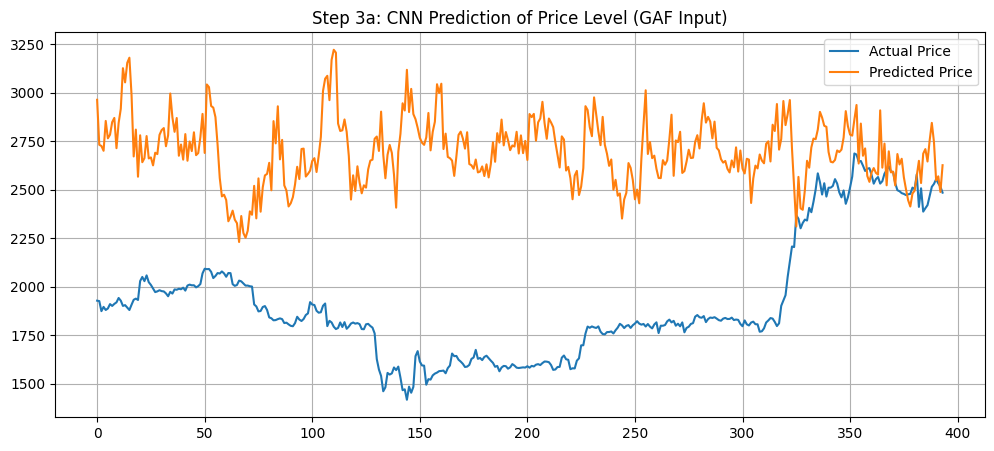

In [ ]:
# === STEP 3a: Prepare Level Series for GAF-CNN Regression ===

# Use the existing 'edf' DataFrame from Step 1
price_series = edf['Close'].values
window_size = 30

# Generate overlapping sequences and corresponding labels (next price)
X_seq = []
y_seq = []
for i in range(window_size, len(price_series) - 1):
    X_seq.append(price_series[i - window_size:i])
    y_seq.append(price_series[i + 1])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Scale each sequence individually to [-1, 1] for GAF
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = np.array([scaler.fit_transform(seq.reshape(-1, 1)).flatten() for seq in X_seq])

# Apply Gramian Angular Field (GAF)
gaf = GramianAngularField()
X_gaf = gaf.transform(X_scaled)  # shape: (samples, 30, 30)

# Add channel dimension for CNN input
X_gaf = X_gaf[..., np.newaxis]  # shape: (samples, 30, 30, 1)

# Split into train/test (no shuffle, time series aware)
X_train, X_test, y_train, y_test = train_test_split(X_gaf, y_seq, test_size=0.2, shuffle=False)

# Scale targets for smoother regression training
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

# === CNN Model for Regression ===

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(window_size, window_size, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Train the model
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict and evaluate
y_pred_scaled = model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled).flatten()

print("\nModel Evaluation:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')
plt.title("Step 3a: CNN Prediction of Price Level (GAF Input)")
plt.legend()
plt.grid(True)
plt.show()


## Step 3B

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,697 (491.00 KB)

 Trainable params: 125,697 (491.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5121 - loss: 0.7358 - val_accuracy: 0.4921 - val_loss: 0.6958
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4983 - loss: 0.7197 - val_accuracy: 0.5048 - val_loss: 0.6947
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5271 - loss: 0.6938 - val_accuracy: 0.5175 - val_loss: 0.6929
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5313 - loss: 0.7004 - val_accuracy: 0.4984 - val_loss: 0.6985
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5457 - loss: 0.6901 - val_accuracy: 0.5016 - val_loss: 0.6957
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4848 - loss: 0.7033 - val_accuracy: 0.4952 - val_loss: 0.6946
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5081 - loss: 0.6968 - val_accuracy: 0.5175 - val_loss: 0.6957
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5114 - loss: 0.6926 - val_accuracy: 0.5048 - 

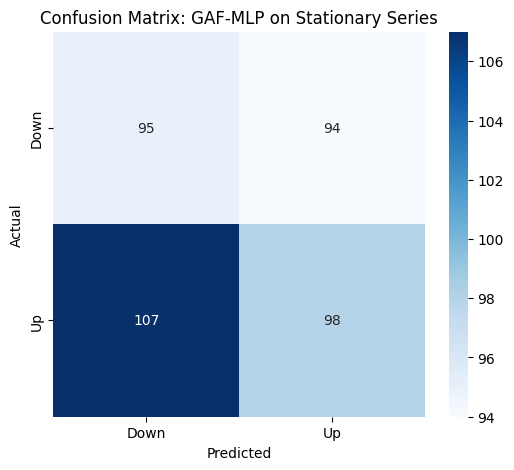

In [ ]:
# === STEP 3b: Prepare GAF images from stationary series (log returns) ===

# Use 'edf["log_returns"]' (already computed in Step 1)
log_ret_series = edf['log_returns'].dropna().values
window_size = 30

# Create overlapping windows and targets
X_seq = []
y_seq = []
for i in range(window_size, len(log_ret_series) - 1):
    window = log_ret_series[i - window_size:i]
    target = log_ret_series[i + 1]
    X_seq.append(window)
    y_seq.append(1 if target > 0 else 0)  # Binary label
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Normalize each sequence to [-1, 1] for GAF
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = np.array([scaler.fit_transform(seq.reshape(-1, 1)).flatten() for seq in X_seq])

# Apply Gramian Angular Field
gaf = GramianAngularField()
X_gaf = gaf.transform(X_scaled)  # (samples, 30, 30)

# Flatten GAF images for MLP input
X_flat = X_gaf.reshape(X_gaf.shape[0], -1)  # (samples, 900)

# Train/test split (no shuffle for time series)
X_train, X_test, y_train, y_test = train_test_split(X_flat, y_seq, test_size=0.2, shuffle=False)

# === Build MLP for classification ===

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_flat.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict and evaluate
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob > 0.5).astype(int)

# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.title("Confusion Matrix: GAF-MLP on Stationary Series")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Step 3C

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,985 (1.20 MB)

 Trainable params: 313,985 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 0.1284 - mae: 0.2486 - val_loss: 0.0496 - val_mae: 0.1819
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0270 - mae: 0.1346 - val_loss: 0.0484 - val_mae: 0.1786
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0269 - mae: 0.1329 - val_loss: 0.0371 - val_mae: 0.1527
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0234 - mae: 0.1249 - val_loss: 0.0292 - val_mae: 0.1331
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0246 - mae: 0.1277 - val_loss: 0.0342 - val_mae: 0.1450
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0224 - mae: 0.1231 - val_loss: 0.0432 - val_mae: 0.1663
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0201 - mae: 0.1131 - val_loss: 0.0529 - val_mae: 0.1869
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0212 - mae: 0.1158 - val_loss: 0.0570 - val_mae: 0.1971
Epoch 9/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - lo

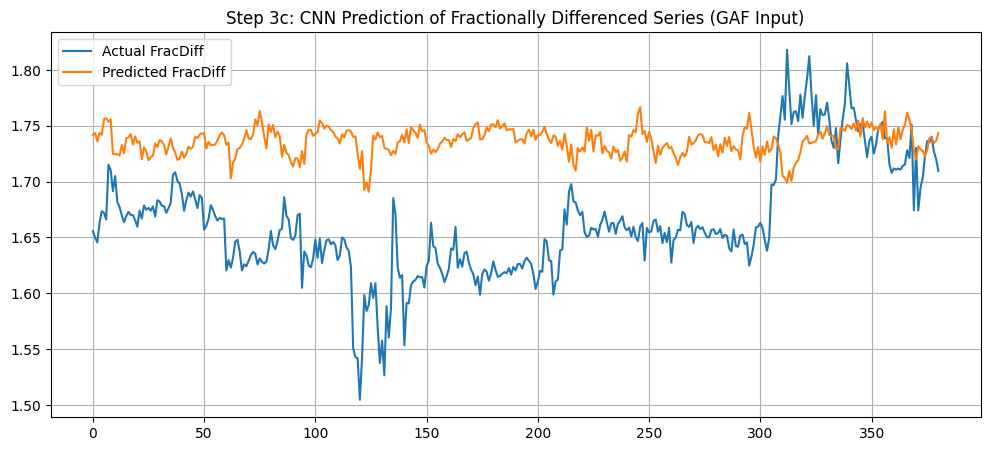

In [ ]:
# === STEP 3c: Prepare Fractionally-Differenced Series ===

# Choose column: 'frac_diff' or 'frac_diff_log_prices'
if 'frac_diff' in fdf1.columns:
    series = fdf1['frac_diff'].dropna().values
elif 'frac_diff_log_prices' in fdf1.columns:
    series = fdf1['frac_diff_log_prices'].dropna().values
else:
    raise ValueError("Fractionally-differenced column not found in fdf1.")

window_size = 30
X_seq, y_seq = [], []

for i in range(window_size, len(series) - 1):
    X_seq.append(series[i - window_size:i])
    y_seq.append(series[i + 1])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Normalize each sequence to [-1, 1] for GAF
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = np.array([scaler.fit_transform(seq.reshape(-1, 1)).flatten() for seq in X_seq])

# Apply Gramian Angular Field
gaf = GramianAngularField()
X_gaf = gaf.transform(X_scaled)  # shape: (samples, 30, 30)

# Add channel dimension
X_gaf = X_gaf[..., np.newaxis]  # shape: (samples, 30, 30, 1)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_gaf, y_seq, test_size=0.2, shuffle=False)

# Normalize targets
target_scaler = MinMaxScaler()
y_train_scaled = target_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = target_scaler.transform(y_test.reshape(-1, 1)).ravel()

# === CNN Model for Regression ===

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(input_shape=(30, 30, 1)),
    tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='linear')  # regression output
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Early stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Predict and inverse scale
y_pred_scaled = model.predict(X_test)
y_pred = target_scaler.inverse_transform(y_pred_scaled).flatten()

# Evaluation
print("\nCNN Evaluation on Fractionally Differenced Series:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Actual FracDiff')
plt.plot(y_pred, label='Predicted FracDiff')
plt.title("Step 3c: CNN Prediction of Fractionally Differenced Series (GAF Input)")
plt.legend()
plt.grid(True)
plt.show()
